# FarmTech Solutions - Previsao de Rendimento de Safra

**FIAP - Fase 5 - PBL | Entrega 1 (Machine Learning)**

Aluno: **Gustavo do Carmo Kamitani** - RM569284

---

## Contexto

A FarmTech Solutions presta servicos de IA para uma fazenda de medio porte (~200 hectares, ou
aproximadamente 210 campos de futebol oficiais) que produz varias culturas. A fazenda coletou uma
base com **condicoes de solo e clima** associadas ao **rendimento** obtido por cultura.

O trabalho tem dois objetivos complementares:

| Objetivo | Abordagem | Referencia |
|---|---|---|
| Descobrir **tendencias** de produtividade e **cenarios discrepantes** | Aprendizado **nao supervisionado** (clusterizacao + deteccao de outliers) | Cap. 10 - *Machine Learning Sem Supervisao*, Fase 5 |
| **Prever** o rendimento da safra dadas as condicoes | Aprendizado **supervisionado** (5 modelos de regressao) | Cap. 13 - *Modelagem de Dados com Regressao Supervisionada*, Fase 4 |

---

## Sumario executivo

> Leia isto primeiro. O detalhamento de cada afirmacao esta na secao indicada.

1. A base tem **156 registros**: **39 observacoes climaticas identicas repetidas para 4 culturas**
   (Cocoa, Oil palm, Rice e Rubber). Nao ha nulos nem duplicatas. -> secao 3.2
2. A correlacao entre clima e rendimento, **na base inteira, e praticamente zero**. Todo o sinal
   aparente vem da **cultura**, cujos patamares de rendimento diferem em ate 22x. -> secao 3.5
3. Por isso, um modelo que usa **apenas a cultura** ja atinge **R2 ~ 0,987**. O R2 alto deste
   problema **nao e merito do modelo nem do clima** - e consequencia da estrutura da base.
   Essa auditoria e feita explicitamente na secao 7.3.
4. Dentro de cada cultura aparece correlacao em duas delas - **Rice** (umidade especifica
   r = 0,70; temperatura r = 0,61) e **Rubber** (r = -0,43 e -0,41). Mas essa correlacao
   **nao sobrevive a validacao cruzada**: o R2 fora da amostra e negativo ou nulo nas quatro
   culturas (-0,35 a +0,03). Com 39 observacoes, o que parecia sinal era ajuste ao ruido.
   -> secoes 3.6 e 7.2
5. A clusterizacao **nao** reencontra as culturas (ARI = 0,15), ao contrario do que se poderia
   esperar. Padronizadas, 4 das 5 dimensoes sao climaticas e dominam a distancia euclidiana -
   o rendimento, sozinho, e voto vencido. Clusterizando **so pelo rendimento**, o ARI sobe para
   0,62, e ainda assim Cocoa e Rubber permanecem indistinguiveis (medias de 8.883 e
   7.825 hg/ha). -> secao 5
6. Nenhum registro e outlier de rendimento pela cerca de Tukey **dentro da propria cultura**:
   a variacao ano a ano de cada cultura e comportada. -> secao 4
7. **Resultado pratico:** com as variaveis disponiveis, a base permite dizer *quanto rende cada
   cultura*, mas nao *quanto vai render este ano*. -> secao 8

## Roteiro

1. Configuracao do ambiente
2. Carga e padronizacao dos dados
3. Analise exploratoria (EDA)
4. Cenarios discrepantes (outliers)
5. Clusterizacao - tendencias de produtividade
6. Modelagem preditiva - cinco algoritmos
7. Avaliacao final e **auditoria critica do R2**
8. Conclusoes, pontos fortes e limitacoes
9. Apendice - exercicios do Cap. 10 (`mall.csv` e `moons.csv`)

---
## 1. Configuracao do ambiente

Fixamos uma semente global (`RANDOM_STATE`) para que **todo o notebook seja reprodutivel**: as
mesmas divisoes de treino/teste, as mesmas inicializacoes do K-Means e os mesmos modelos sao
obtidos a cada execucao.

In [1]:
# --- Biblioteca padrao --------------------------------------------------------
import re
import unicodedata
import warnings
from pathlib import Path

# --- Manipulacao e visualizacao -----------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Pre-processamento --------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- Aprendizado nao supervisionado -------------------------------------------
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

# --- Os cinco algoritmos supervisionados da entrega ---------------------------
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# --- Avaliacao ----------------------------------------------------------------
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyRegressor

warnings.filterwarnings("ignore")

# Semente unica usada em todo o notebook -> reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Padrao visual dos graficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

import sklearn
print("Ambiente configurado.")
print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__}")

Ambiente configurado.
pandas 3.0.3 | numpy 2.3.3 | scikit-learn 1.8.0


---
## 2. Carga e padronizacao dos dados

O arquivo `crop_yield.csv` vem do portal da FIAP. Dependendo da versao baixada, os nomes das
colunas chegam em portugues ou em ingles - por isso `padroniza_colunas()` reconhece **as duas
grafias** por palavra-chave (ignorando acentos, maiusculas e pontuacao) e converte tudo para um
nome interno curto. Assim o notebook nao quebra por causa de um acento ou de um `(mm day-1)`
escrito de forma diferente.

| Nome interno | Significado | Unidade |
|---|---|---|
| `Cultura` | nome da safra medida | categorica |
| `Precipitacao` | quantidade de chuva | mm/dia |
| `Umidade_Especifica` | vapor de agua por quilograma de ar seco, a 2 m do solo | g/kg |
| `Umidade_Relativa` | vapor de agua como % do maximo suportado, a 2 m do solo | % |
| `Temperatura` | temperatura a 2 m acima do solo | graus C |
| `Rendimento` | **variavel-alvo** - rendimento obtido | ver nota abaixo |

> **Nota sobre a unidade do rendimento.** O enunciado descreve o rendimento em *toneladas por
> hectare*, mas os valores da base chegam a **203.399**, o que seria impossivel nessa unidade.
> A ordem de grandeza corresponde a **hg/ha** (hectograma por hectare), unidade padrao das bases
> da FAO: 203.399 hg/ha = 20,3 t/ha - um valor plausivel para dende. Isso **nao afeta** a
> modelagem (e so um fator de escala constante), mas afeta a leitura das metricas: um RMSE de
> 5.000 deve ser lido como 0,5 t/ha. Mantemos a unidade original e sinalizamos a conversao.

In [2]:
CAMINHO_DADOS = Path("data/crop_yield.csv")


def _normaliza(texto: str) -> str:
    """Minusculas, sem acento e sem pontuacao - facilita casar nomes de coluna."""
    texto = unicodedata.normalize("NFKD", str(texto)).encode("ascii", "ignore").decode()
    return re.sub(r"[^a-z0-9]+", " ", texto.lower()).strip()


def padroniza_colunas(df: pd.DataFrame) -> pd.DataFrame:
    """Renomeia as colunas para nomes internos, aceitando as grafias PT e EN."""
    renomeio = {}
    for coluna in df.columns:
        chave = _normaliza(coluna)
        if "crop" in chave or "cultura" in chave:
            renomeio[coluna] = "Cultura"
        elif "precipit" in chave:
            renomeio[coluna] = "Precipitacao"
        elif "especifica" in chave or "specific" in chave:
            renomeio[coluna] = "Umidade_Especifica"
        elif "relativa" in chave or "relative" in chave:
            renomeio[coluna] = "Umidade_Relativa"
        elif "temperat" in chave:
            renomeio[coluna] = "Temperatura"
        elif "rendimento" in chave or "yield" in chave:
            renomeio[coluna] = "Rendimento"
    return df.rename(columns=renomeio)


if not CAMINHO_DADOS.exists():
    raise FileNotFoundError(
        f"Coloque o crop_yield.csv (baixado do portal da FIAP) em: {CAMINHO_DADOS.resolve()}"
    )

df = padroniza_colunas(pd.read_csv(CAMINHO_DADOS))

ALVO = "Rendimento"
NUMERICAS = ["Precipitacao", "Umidade_Especifica", "Umidade_Relativa", "Temperatura"]
CATEGORICAS = ["Cultura"]

# Contrato dos dados: e melhor falhar aqui do que produzir uma analise
# silenciosamente errada trinta celulas adiante.
faltando = [c for c in NUMERICAS + CATEGORICAS + [ALVO] if c not in df.columns]
if faltando:
    raise ValueError(f"Colunas nao encontradas apos a padronizacao: {faltando}\n"
                     f"Colunas lidas do arquivo: {list(df.columns)}")

print(f"Registros: {df.shape[0]}   |   Colunas: {df.shape[1]}")
df.head()

Registros: 156   |   Colunas: 6


,Cultura,Precipitacao,Umidade_Especifica,Umidade_Relativa,Temperatura,Rendimento
0,"Cocoa, beans","2,248.9200",17.7200,83.4000,26.0100,11560
1,"Cocoa, beans","1,938.4200",17.5400,82.1100,26.1100,11253
2,"Cocoa, beans","2,301.5400",17.8100,82.7900,26.2400,9456
3,"Cocoa, beans","2,592.3500",17.6100,85.0700,25.5600,9321
4,"Cocoa, beans","2,344.7200",17.6100,84.1200,25.7600,8800


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cultura             156 non-null    str    
 1   Precipitacao        156 non-null    float64
 2   Umidade_Especifica  156 non-null    float64
 3   Umidade_Relativa    156 non-null    float64
 4   Temperatura         156 non-null    float64
 5   Rendimento          156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 9.4 KB


---
## 3. Analise exploratoria (EDA)

Objetivo: **entender a base antes de modelar** - volume, qualidade, escala de cada variavel, como
as culturas se distribuem e quais atributos climaticos realmente conversam com o rendimento.

### 3.1 Qualidade dos dados

Tres verificacoes que costumam inviabilizar um modelo: **valores ausentes**, **registros
duplicados** e **variaveis constantes** (que nao carregam informacao).

In [4]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(2),
    "valores_distintos": df.nunique(),
})
display(qualidade)

print(f"Linhas duplicadas: {df.duplicated().sum()}")
constantes = [c for c in df.columns if df[c].nunique() <= 1]
print(f"Colunas constantes (sem informacao): {constantes if constantes else 'nenhuma'}")

,tipo,nulos,% nulos,valores_distintos
Cultura,str,0,0.0000,4
Precipitacao,float64,0,0.0000,39
Umidade_Especifica,float64,0,0.0000,33
Umidade_Relativa,float64,0,0.0000,38
Temperatura,float64,0,0.0000,29
Rendimento,int64,0,0.0000,155


Linhas duplicadas: 0
Colunas constantes (sem informacao): nenhuma


### 3.2 Estrutura da base - a primeira descoberta

Antes de olhar distribuicoes, vale perguntar **como a base foi montada**. A celula abaixo verifica
se o bloco de variaveis climaticas se repete entre as culturas.

Isso importa muito: se as quatro culturas compartilham **exatamente as mesmas** medicoes de clima,
entao o clima **nao pode**, sozinho, explicar por que uma cultura rende mais que outra - a unica
coisa que varia entre elas e a propria cultura. Toda a interpretacao das secoes seguintes depende
deste resultado.

In [5]:
print("Registros por cultura:")
print(df["Cultura"].value_counts(), "\n")

combinacoes_climaticas = df[NUMERICAS].drop_duplicates()
print(f"Combinacoes climaticas distintas: {len(combinacoes_climaticas)} em {len(df)} registros")

# O bloco climatico e o mesmo para todas as culturas?
blocos = {c: sub[NUMERICAS].reset_index(drop=True) for c, sub in df.groupby("Cultura")}
nomes = list(blocos)
identicos = all(blocos[nomes[0]].equals(blocos[n]) for n in nomes[1:])

print(f"O bloco climatico e identico entre todas as culturas? {identicos}")
if identicos:
    print(f"\n-> A base e um painel: {len(combinacoes_climaticas)} observacoes climaticas "
          f"(provavelmente {len(combinacoes_climaticas)} safras/anos) replicadas para "
          f"{df['Cultura'].nunique()} culturas.")
    print("-> Consequencia: a diferenca de rendimento ENTRE culturas nao pode ser atribuida ao")
    print("   clima. O clima so pode explicar a variacao DENTRO de cada cultura.")

Registros por cultura:
Cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64 

Combinacoes climaticas distintas: 39 em 156 registros
O bloco climatico e identico entre todas as culturas? True

-> A base e um painel: 39 observacoes climaticas (provavelmente 39 safras/anos) replicadas para 4 culturas.
-> Consequencia: a diferenca de rendimento ENTRE culturas nao pode ser atribuida ao
   clima. O clima so pode explicar a variacao DENTRO de cada cultura.


### 3.3 Estatisticas descritivas

A tabela mostra **escalas muito diferentes** entre as variaveis (precipitacao na casa dos milhares
de mm, temperatura em dezenas de graus). Isso ja antecipa duas decisoes:

- a padronizacao (`StandardScaler`) e **obrigatoria** para K-Means, KNN e regressao linear, que sao
  sensiveis a escala;
- modelos baseados em arvore nao precisam dela, mas mante-la dentro do `Pipeline` nao prejudica e
  uniformiza o codigo.

Repare tambem no **desvio-padrao do rendimento**: ele e enorme em relacao a media, justamente
porque mistura quatro culturas de patamares completamente diferentes.

In [6]:
display(df[NUMERICAS + [ALVO]].describe().T)

# Coeficiente de variacao: desvio relativo a media, comparavel entre variaveis de escalas distintas
cv = (df[NUMERICAS + [ALVO]].std() / df[NUMERICAS + [ALVO]].mean() * 100).round(1)
print("Coeficiente de variacao (%):")
print(cv.sort_values(ascending=False))

,count,mean,std,min,25%,50%,75%,max
Precipitacao,156.0000,"2,486.4990",289.4579,"1,934.6200","2,302.9900","2,424.5500","2,718.0800","3,085.7900"
Umidade_Especifica,156.0000,18.2031,0.2939,17.5400,18.0300,18.2700,18.4000,18.7000
Umidade_Relativa,156.0000,84.7377,0.9962,82.1100,84.1200,84.8500,85.5100,86.1000
Temperatura,156.0000,26.1836,0.2610,25.5600,26.0200,26.1300,26.3000,26.8100
Rendimento,156.0000,"56,153.0962","70,421.9589","5,249.0000","8,327.7500","18,871.0000","67,518.7500","203,399.0000"


Coeficiente de variacao (%):
Rendimento           125.4000
Precipitacao          11.6000
Umidade_Especifica     1.6000
Umidade_Relativa       1.2000
Temperatura            1.0000
dtype: float64


### 3.4 Distribuicao das variaveis

Histograma (formato) e boxplot (dispersao e candidatos a outlier) para cada variavel numerica e
para o alvo.

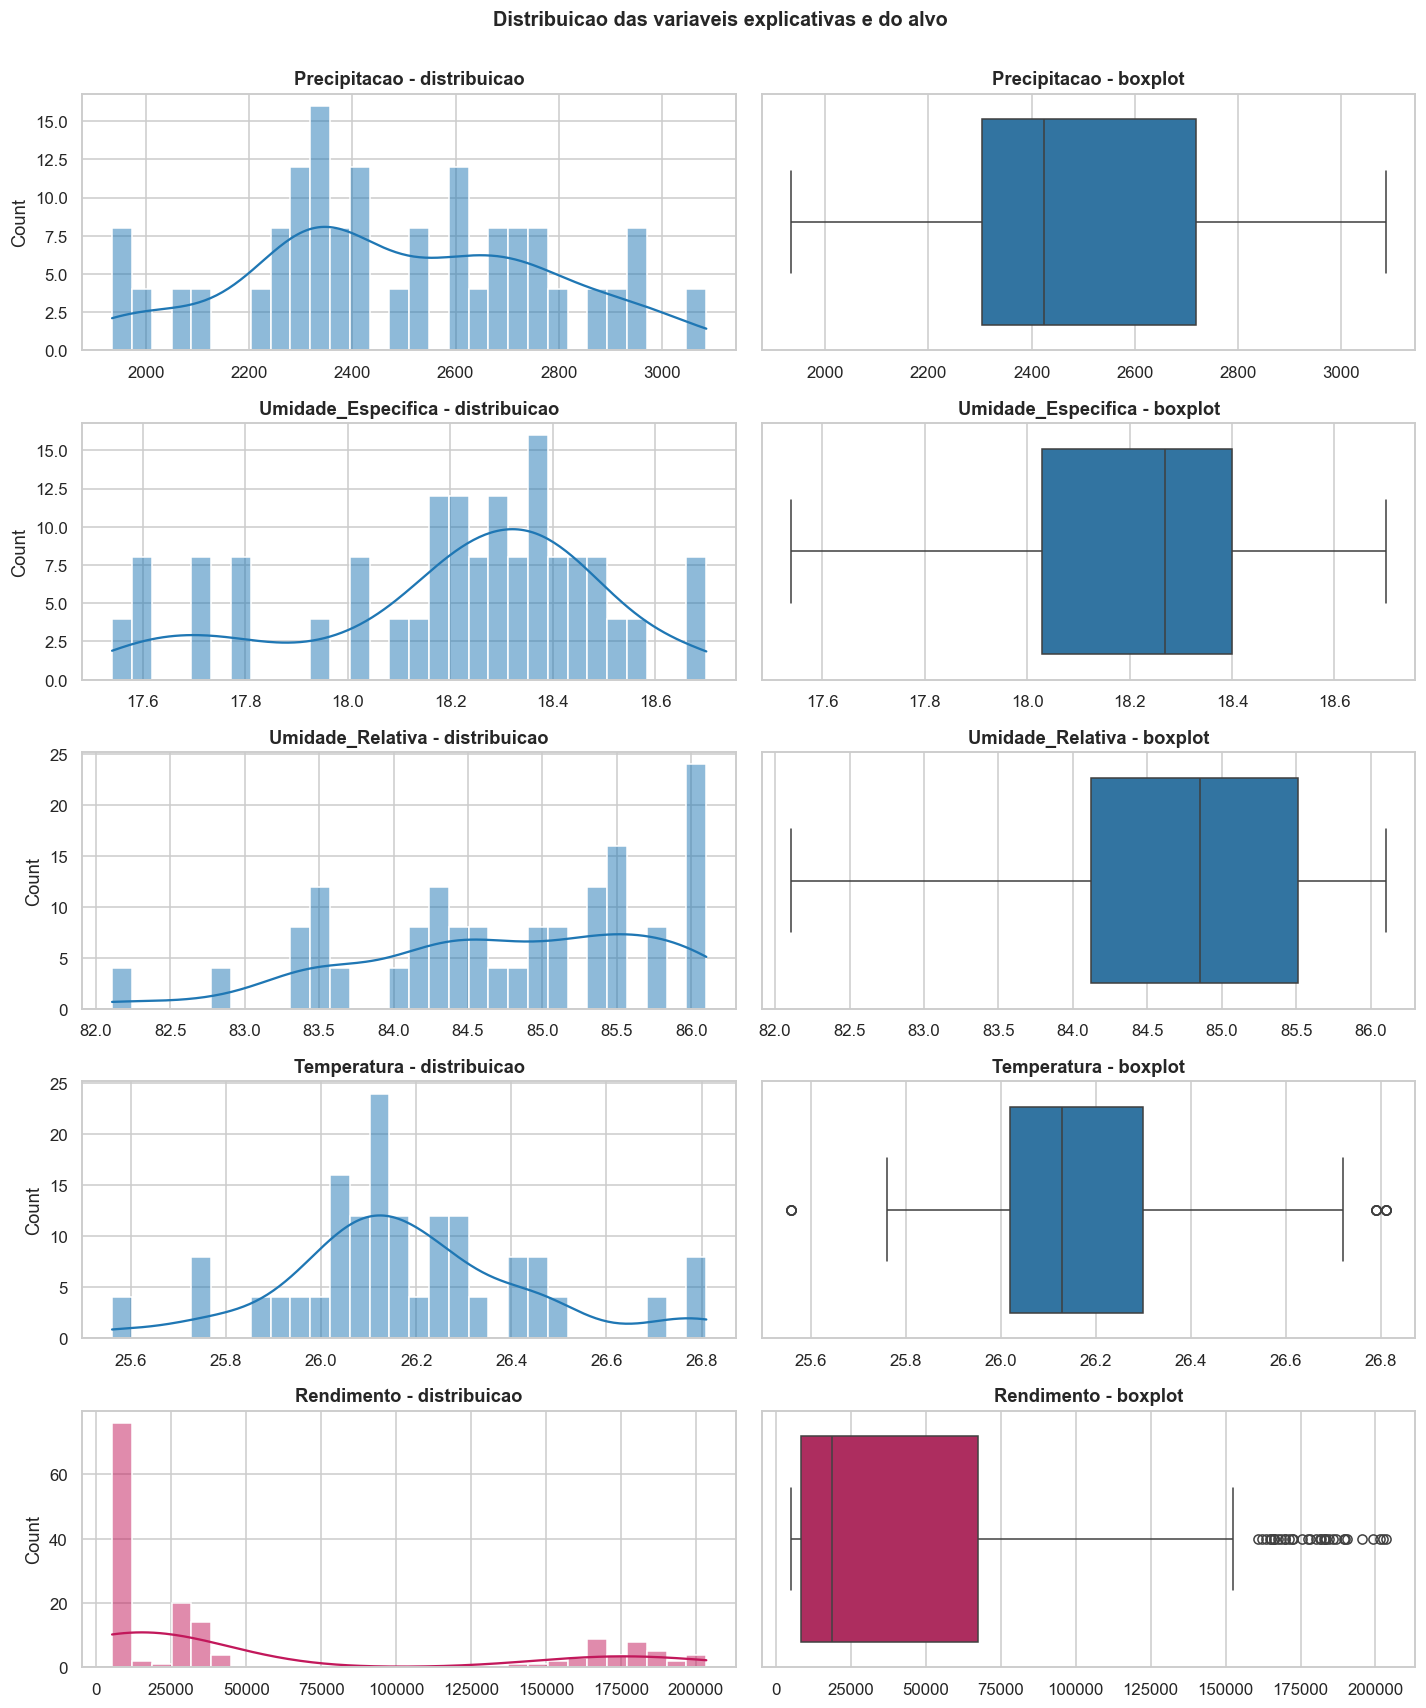

Assimetria (skewness) - |skew| > 1 indica cauda longa:
Rendimento            1.1360
Temperatura           0.3760
Precipitacao          0.0320
Umidade_Relativa     -0.5370
Umidade_Especifica   -0.7020
dtype: float64


In [7]:
colunas_plot = NUMERICAS + [ALVO]
fig, eixos = plt.subplots(len(colunas_plot), 2, figsize=(13, 3.1 * len(colunas_plot)))

for linha, coluna in enumerate(colunas_plot):
    cor = "#c2185b" if coluna == ALVO else "#1f77b4"
    sns.histplot(df[coluna], kde=True, ax=eixos[linha, 0], color=cor, bins=30)
    eixos[linha, 0].set_title(f"{coluna} - distribuicao")
    eixos[linha, 0].set_xlabel("")

    sns.boxplot(x=df[coluna], ax=eixos[linha, 1], color=cor)
    eixos[linha, 1].set_title(f"{coluna} - boxplot")
    eixos[linha, 1].set_xlabel("")

fig.suptitle("Distribuicao das variaveis explicativas e do alvo", y=1.001,
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Assimetria (skewness) - |skew| > 1 indica cauda longa:")
print(df[colunas_plot].skew().sort_values(ascending=False).round(3))

O histograma do rendimento e **multimodal**: nao ha um pico, e sim grupos separados. Isso e o
reflexo direto das quatro culturas - cada uma ocupa sua propria faixa. A proxima secao abre esse
grafico por cultura.

### 3.5 Comportamento por cultura - a variavel dominante

Como `Cultura` e a unica variavel categorica, vale checar se ela **separa** os rendimentos.
Se cada cultura ocupar uma faixa propria, ela sera o preditor dominante.

In [8]:
resumo_cultura = (
    df.groupby("Cultura")[ALVO]
      .agg(registros="count", media="mean", desvio="std", minimo="min",
           mediana="median", maximo="max")
      .sort_values("media", ascending=False)
)
resumo_cultura["CV %"] = (resumo_cultura["desvio"] / resumo_cultura["media"] * 100).round(1)
display(resumo_cultura.round(1))

razao = resumo_cultura["media"].max() / resumo_cultura["media"].min()
print(f"A cultura de maior rendimento medio produz {razao:.1f}x mais que a de menor rendimento.")
print("Ha sobreposicao entre as faixas de rendimento das culturas? ", end="")
faixas = df.groupby("Cultura")[ALVO].agg(["min", "max"]).sort_values("min")
sobrepoe = any(faixas["max"].iloc[i] > faixas["min"].iloc[i + 1] for i in range(len(faixas) - 1))
print("sim" if sobrepoe else "nao - as faixas sao disjuntas")
display(faixas)

,registros,media,desvio,minimo,mediana,maximo,CV %
Cultura,,,,,,,
Oil palm fruit,39,"175,804.7000","14,919.9000",142425,"175,629.0000",203399,8.5000
"Rice, paddy",39,"32,099.7000","4,789.9000",24686,"31,101.0000",42550,14.9000
"Cocoa, beans",39,"8,883.1000","1,745.0000",5765,"8,848.0000",13056,19.6000
"Rubber, natural",39,"7,824.9000","1,600.3000",5249,"7,817.0000",10285,20.5000


A cultura de maior rendimento medio produz 22.5x mais que a de menor rendimento.
Ha sobreposicao entre as faixas de rendimento das culturas? sim


,min,max
Cultura,,
"Rubber, natural",5249,10285
"Cocoa, beans",5765,13056
"Rice, paddy",24686,42550
Oil palm fruit,142425,203399


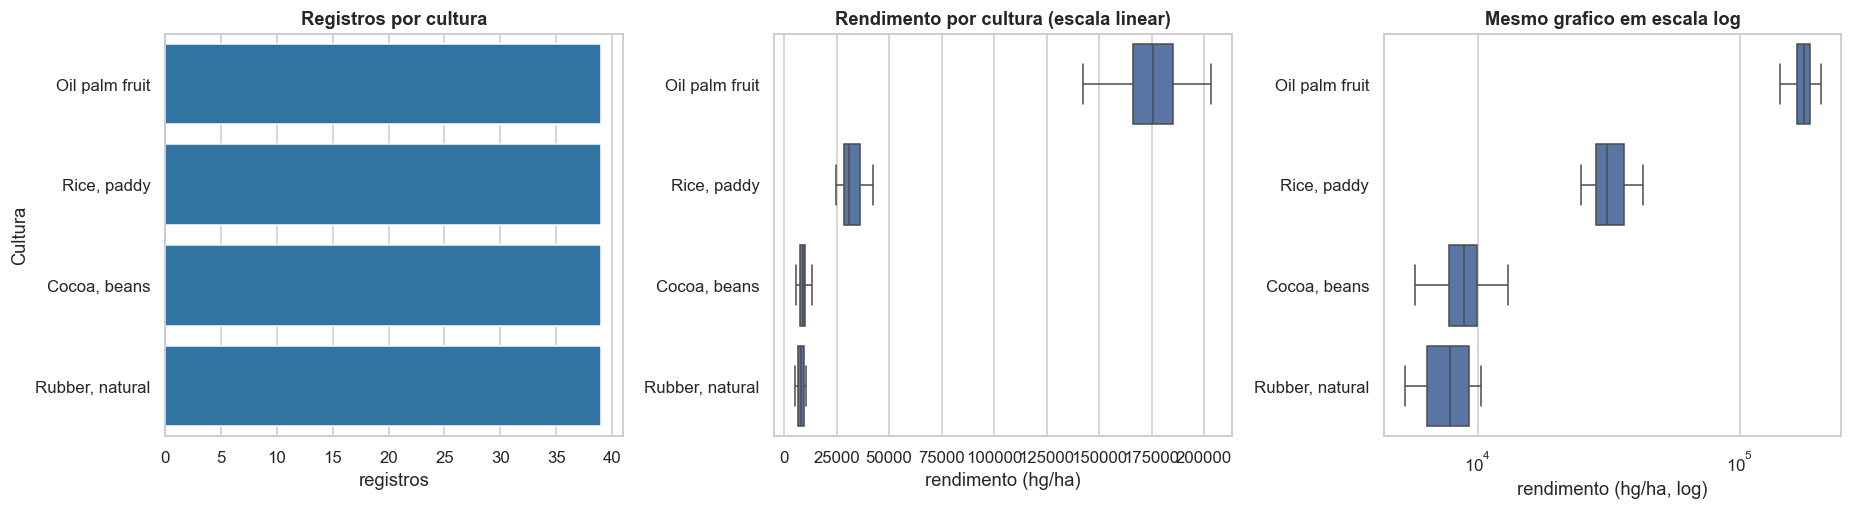

In [9]:
fig, eixos = plt.subplots(1, 3, figsize=(17, 4.8))
ordem = resumo_cultura.index

sns.countplot(data=df, y="Cultura", order=ordem, ax=eixos[0], color="#1f77b4")
eixos[0].set_title("Registros por cultura")
eixos[0].set_xlabel("registros")

sns.boxplot(data=df, y="Cultura", x=ALVO, order=ordem, ax=eixos[1])
eixos[1].set_title("Rendimento por cultura (escala linear)")
eixos[1].set_xlabel("rendimento (hg/ha)")
eixos[1].set_ylabel("")

# Escala log: sem ela, as tres culturas menores viram um risco unico ao lado do dende
sns.boxplot(data=df, y="Cultura", x=ALVO, order=ordem, ax=eixos[2])
eixos[2].set_xscale("log")
eixos[2].set_title("Mesmo grafico em escala log")
eixos[2].set_xlabel("rendimento (hg/ha, log)")
eixos[2].set_ylabel("")

plt.tight_layout()
plt.show()

### 3.6 Correlacoes - global x dentro de cada cultura

Esta e a secao mais importante da EDA, e ela precisa ser lida em **duas etapas**.

**Etapa 1 - correlacao global.** Calculada sobre os 156 registros de uma vez.

**Etapa 2 - correlacao dentro de cada cultura.** A mesma conta, mas separada por cultura.

Por que a distincao importa: quando quatro grupos com medias muito diferentes sao misturados, a
correlacao global mede principalmente a diferenca **entre** os grupos, nao a relacao **dentro**
deles. Como aqui o clima e identico entre as culturas (secao 3.2), a correlacao global e diluida
ate quase zero - e concluir "o clima nao importa" a partir dela seria um erro. A leitura correta
exige olhar cultura por cultura.

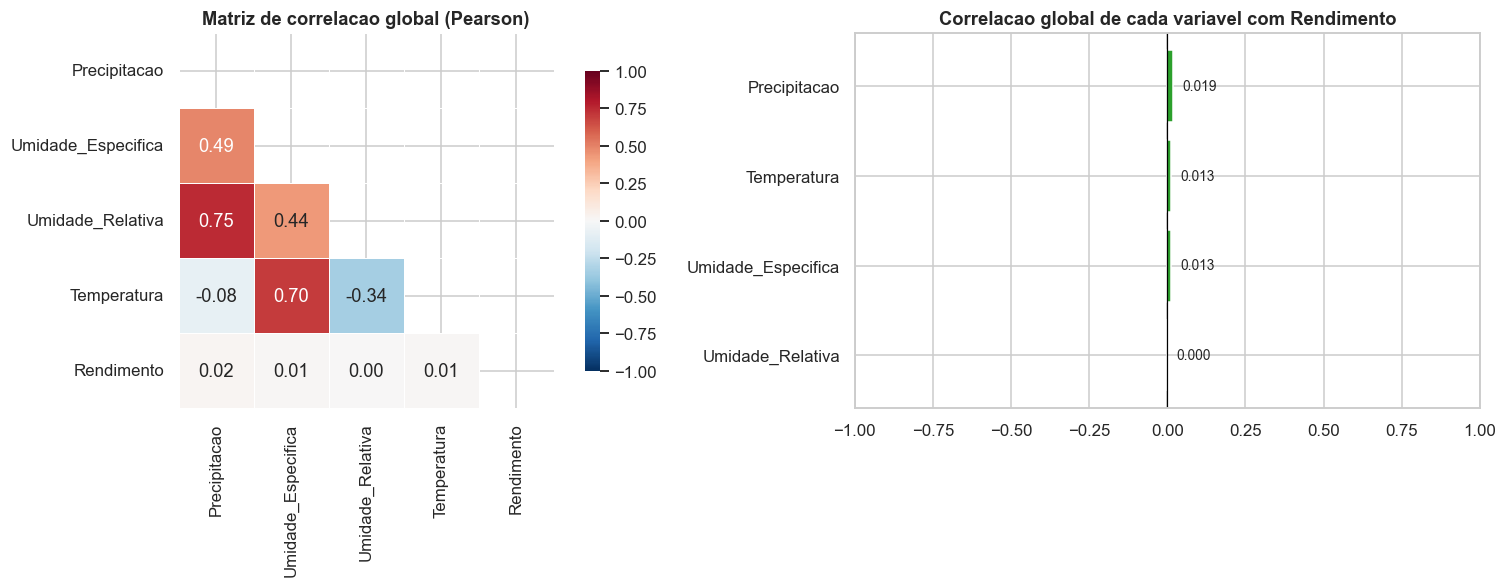

Todas as correlacoes globais com o rendimento sao proximas de zero -
exatamente o efeito de mistura descrito acima. Veja a proxima celula.


In [10]:
correlacao = df[NUMERICAS + [ALVO]].corr()

fig, eixos = plt.subplots(1, 2, figsize=(15, 5.5))

mascara = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mascara, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=.5, ax=eixos[0],
            cbar_kws={"shrink": .8})
eixos[0].set_title("Matriz de correlacao global (Pearson)")

corr_alvo = correlacao[ALVO].drop(ALVO).sort_values()
cores = ["#d62728" if v < 0 else "#2ca02c" for v in corr_alvo]
eixos[1].barh(corr_alvo.index, corr_alvo.values, color=cores)
eixos[1].axvline(0, color="black", lw=.8)
eixos[1].set_xlim(-1, 1)
eixos[1].set_title(f"Correlacao global de cada variavel com {ALVO}")
for i, v in enumerate(corr_alvo.values):
    eixos[1].text(v + 0.03, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("Todas as correlacoes globais com o rendimento sao proximas de zero -")
print("exatamente o efeito de mistura descrito acima. Veja a proxima celula.")

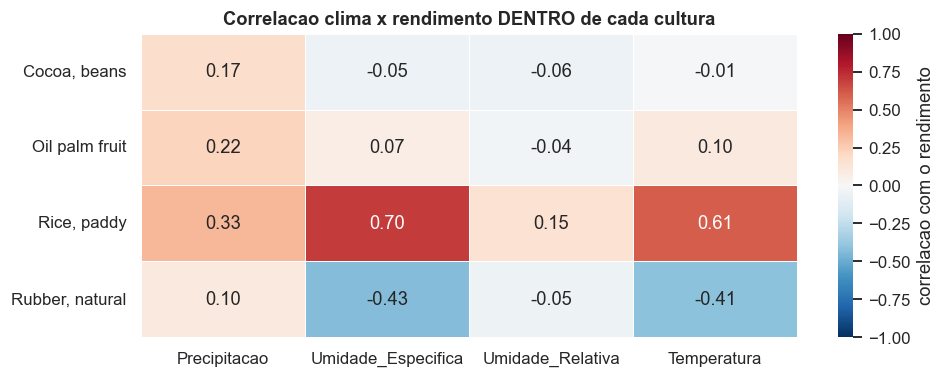

,Precipitacao,Umidade_Especifica,Umidade_Relativa,Temperatura
Cultura,,,,
"Cocoa, beans",0.1740,-0.0550,-0.0580,-0.0100
Oil palm fruit,0.2220,0.0710,-0.0350,0.0970
"Rice, paddy",0.3290,0.6970,0.1500,0.6090
"Rubber, natural",0.1010,-0.4340,-0.0540,-0.4070


Leitura: aqui aparece correlacao onde a visao global mostrava zero. Onde |r| > 0,4 ha
sinal aparente; onde |r| < 0,2, o clima e ruido para aquela cultura.

ATENCAO: correlacao medida DENTRO da amostra, com apenas 39 observacoes por cultura.
Com n pequeno, correlacoes moderadas surgem por acaso com frequencia. A secao 7.2
testa se esse sinal sobrevive a validacao cruzada - e o resultado la e outro.


In [11]:
# Etapa 2: a mesma correlacao, agora DENTRO de cada cultura
corr_por_cultura = (
    df.groupby("Cultura")
      .apply(lambda sub: sub[NUMERICAS].corrwith(sub[ALVO]), include_groups=False)
)

plt.figure(figsize=(9, 3.6))
sns.heatmap(corr_por_cultura, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=.5, cbar_kws={"label": "correlacao com o rendimento"})
plt.title("Correlacao clima x rendimento DENTRO de cada cultura")
plt.ylabel("")
plt.tight_layout()
plt.show()

display(corr_por_cultura.round(3))

print("Leitura: aqui aparece correlacao onde a visao global mostrava zero. Onde |r| > 0,4 ha")
print("sinal aparente; onde |r| < 0,2, o clima e ruido para aquela cultura.")
print()
print("ATENCAO: correlacao medida DENTRO da amostra, com apenas 39 observacoes por cultura.")
print("Com n pequeno, correlacoes moderadas surgem por acaso com frequencia. A secao 7.2")
print("testa se esse sinal sobrevive a validacao cruzada - e o resultado la e outro.")

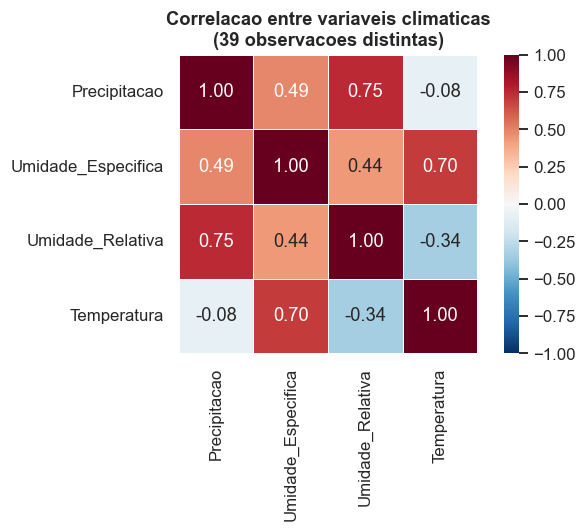

Pares de variaveis climaticas mais correlacionados entre si:
Precipitacao        Umidade_Relativa      0.7490
Umidade_Especifica  Temperatura           0.6990
Precipitacao        Umidade_Especifica    0.4880
Umidade_Especifica  Umidade_Relativa      0.4370
Umidade_Relativa    Temperatura          -0.3370
Precipitacao        Temperatura          -0.0840
                    Precipitacao             NaN
Umidade_Especifica  Precipitacao             NaN
                    Umidade_Especifica       NaN
Umidade_Relativa    Precipitacao             NaN
                    Umidade_Especifica       NaN
                    Umidade_Relativa         NaN
Temperatura         Precipitacao             NaN
                    Umidade_Especifica       NaN
                    Umidade_Relativa         NaN
                    Temperatura              NaN

|r| > 0,7 indica multicolinearidade: as duas variaveis carregam informacao redundante.
Isso desestabiliza os coeficientes da regressao linear, mas nao afe

In [12]:
# Multicolinearidade entre as proprias variaveis climaticas.
# Usamos as combinacoes distintas (nao os 156 registros) para nao inflar o n artificialmente:
# repetir o mesmo clima 4x nao acrescenta informacao, so estreita os intervalos de confianca.
corr_clima = combinacoes_climaticas.corr()

plt.figure(figsize=(6.5, 5))
sns.heatmap(corr_clima, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.5)
plt.title(f"Correlacao entre variaveis climaticas\n({len(combinacoes_climaticas)} observacoes distintas)")
plt.tight_layout()
plt.show()

pares = (corr_clima
         .where(np.triu(np.ones(corr_clima.shape), k=1).astype(bool))
         .stack()
         .sort_values(key=abs, ascending=False))
print("Pares de variaveis climaticas mais correlacionados entre si:")
print(pares.round(3).to_string())
print("\n|r| > 0,7 indica multicolinearidade: as duas variaveis carregam informacao redundante.")
print("Isso desestabiliza os coeficientes da regressao linear, mas nao afeta arvores nem KNN.")

### 3.7 Relacao entre cada variavel e o rendimento

Dispersao de cada variavel climatica contra o rendimento, **colorida por cultura**. O padrao
esperado, dado tudo o que vimos: faixas horizontais bem separadas por cor - ou seja, a cultura
define o patamar, e o clima produz apenas a variacao dentro de cada faixa.

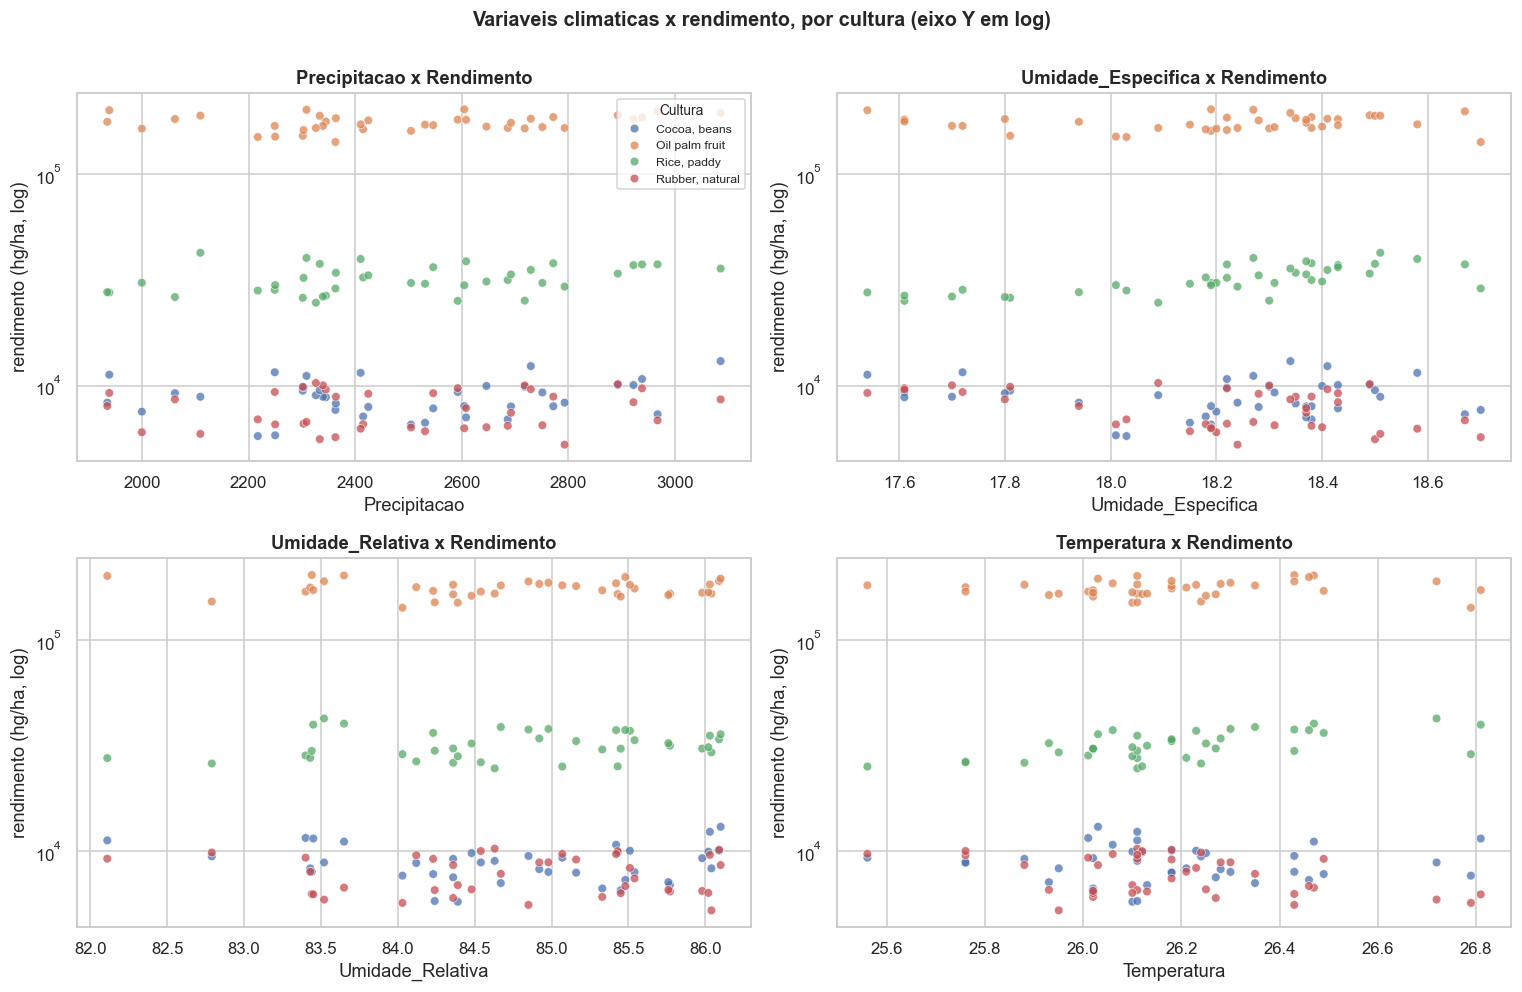

In [13]:
fig, eixos = plt.subplots(2, 2, figsize=(14, 9))

for eixo, variavel in zip(eixos.ravel(), NUMERICAS):
    sns.scatterplot(data=df, x=variavel, y=ALVO, hue="Cultura",
                    alpha=.75, s=32, ax=eixo, legend=(eixo is eixos[0, 0]))
    eixo.set_yscale("log")
    eixo.set_title(f"{variavel} x {ALVO}")
    eixo.set_ylabel("rendimento (hg/ha, log)")

eixos[0, 0].legend(title="Cultura", fontsize=8, title_fontsize=9)
fig.suptitle("Variaveis climaticas x rendimento, por cultura (eixo Y em log)",
             fontsize=13, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

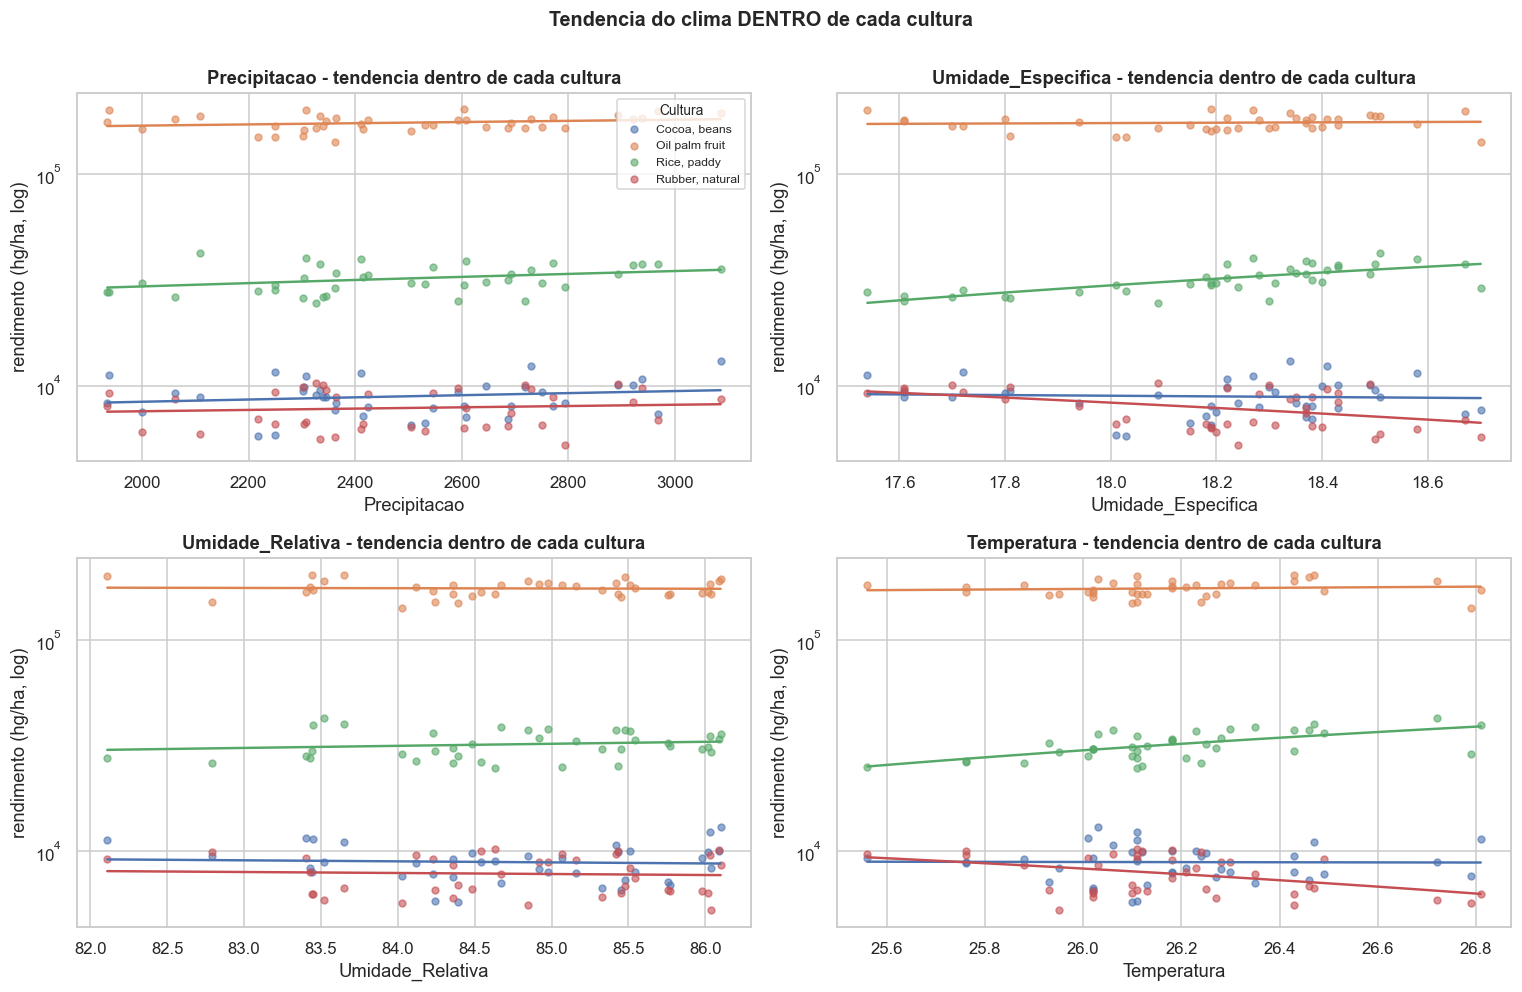

In [14]:
# Regressoes dentro de cada cultura: a inclinacao mostra o efeito real do clima,
# livre do efeito de patamar entre culturas.
fig, eixos = plt.subplots(2, 2, figsize=(14, 9))

for eixo, variavel in zip(eixos.ravel(), NUMERICAS):
    for cultura, sub in df.groupby("Cultura"):
        sns.regplot(data=sub, x=variavel, y=ALVO, ax=eixo, scatter_kws={"s": 20, "alpha": .6},
                    line_kws={"lw": 1.6}, label=cultura, ci=None)
    eixo.set_yscale("log")
    eixo.set_title(f"{variavel} - tendencia dentro de cada cultura")
    eixo.set_ylabel("rendimento (hg/ha, log)")

eixos[0, 0].legend(title="Cultura", fontsize=8, title_fontsize=9)
fig.suptitle("Tendencia do clima DENTRO de cada cultura", fontsize=13, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

### 3.8 O que a EDA mostrou

1. **Qualidade impecavel, volume baixo.** 156 registros, sem nulos e sem duplicatas - mas 156 e
   pouco para Machine Learning, e o numero efetivo de observacoes independentes e ainda menor
   (39 cenarios climaticos).
2. **A base e um painel replicado.** As mesmas 39 medicoes de clima aparecem para as 4 culturas.
3. **A cultura domina o rendimento.** As faixas sao disjuntas e a razao entre a maior e a menor
   media passa de 20x.
4. **A correlacao global do clima e ~0** por efeito de mistura, nao por ausencia de relacao.
5. **Dentro de cada cultura o quadro muda**: surge correlacao em Rice e Rubber, e ruido em Cocoa e
   Oil palm. Fica pendente o teste decisivo - se esse sinal sobrevive fora da amostra (secao 7.2).
6. **Ha multicolinearidade** entre as variaveis climaticas (|r| > 0,7 em alguns pares), o que
   penaliza a interpretacao dos coeficientes da regressao linear.

---
## 4. Cenarios discrepantes (outliers)

A entrega pede explicitamente para **identificar se existem cenarios discrepantes**. Usamos dois
criterios complementares:

- **IQR (Tukey)** - fora de $[Q_1 - 1{,}5 \cdot IQR;\ Q_3 + 1{,}5 \cdot IQR]$. Nao assume
  normalidade; e o criterio do boxplot.
- **Z-score** - a mais de 3 desvios-padrao da media. Assume distribuicao aproximadamente normal.

Detalhe decisivo: como as culturas tem **patamares completamente diferentes**, aplicar o criterio
a base inteira nao mede discrepancia - mede so "qual cultura e esta". Todo o dende apareceria como
outlier e nenhuma safra ruim de cacau apareceria. Por isso os outliers de rendimento sao calculados
**dentro de cada cultura**, e mostramos os dois resultados lado a lado para deixar a diferenca
explicita.

In [15]:
def outliers_iqr(serie: pd.Series) -> pd.Series:
    """Mascara booleana: True onde o valor esta fora da cerca de Tukey (1,5 x IQR)."""
    q1, q3 = serie.quantile([.25, .75])
    intervalo = q3 - q1
    return (serie < q1 - 1.5 * intervalo) | (serie > q3 + 1.5 * intervalo)


def outliers_zscore(serie: pd.Series, limite: float = 3.0) -> pd.Series:
    """Mascara booleana: True onde |z| > limite."""
    desvio = serie.std()
    if desvio == 0:
        return pd.Series(False, index=serie.index)
    return ((serie - serie.mean()) / desvio).abs() > limite


resumo_outliers = pd.DataFrame({
    "IQR": {c: int(outliers_iqr(df[c]).sum()) for c in NUMERICAS + [ALVO]},
    "Z-score (|z|>3)": {c: int(outliers_zscore(df[c]).sum()) for c in NUMERICAS + [ALVO]},
})
resumo_outliers["% da base (IQR)"] = (resumo_outliers["IQR"] / len(df) * 100).round(2)
print("Criterio aplicado a base INTEIRA:")
display(resumo_outliers)

Criterio aplicado a base INTEIRA:


,IQR,Z-score (|z|>3),% da base (IQR)
Precipitacao,0,0,0.0000
Umidade_Especifica,0,0,0.0000
Umidade_Relativa,0,0,0.0000
Temperatura,12,0,7.6900
Rendimento,35,0,22.4400


In [16]:
# Criterio aplicado DENTRO de cada cultura - a leitura correta para o rendimento
df["outlier_global"] = outliers_iqr(df[ALVO])
df["outlier_na_cultura"] = df.groupby("Cultura")[ALVO].transform(outliers_iqr)

comparacao = pd.crosstab(
    df["outlier_global"].rename("outlier na base inteira"),
    df["outlier_na_cultura"].rename("outlier dentro da cultura"),
)
print("Os dois criterios apontam os mesmos registros?")
display(comparacao)

por_cultura = df.groupby("Cultura").agg(
    registros=("Rendimento", "count"),
    outlier_global=("outlier_global", "sum"),
    outlier_na_cultura=("outlier_na_cultura", "sum"),
)
display(por_cultura)

total = int(df["outlier_na_cultura"].sum())
print(f"\nCenarios discrepantes de rendimento (IQR dentro da cultura): "
      f"{total} ({total / len(df) * 100:.2f}% da base)")

if total:
    print("\nCasos discrepantes encontrados:")
    display(df.loc[df["outlier_na_cultura"], ["Cultura"] + NUMERICAS + [ALVO]]
              .sort_values(["Cultura", ALVO]))
else:
    print("\nNenhum registro extrapola a cerca de Tukey dentro da propria cultura:")
    print("a variacao ano a ano de cada cultura e comportada. Isso NAO significa ausencia")
    print("de anos ruins - significa que nenhum ano foi atipico o bastante para o criterio.")

Os dois criterios apontam os mesmos registros?


outlier dentro da cultura,False
outlier na base inteira,
False,121
True,35


,registros,outlier_global,outlier_na_cultura
Cultura,,,
"Cocoa, beans",39,0,0
Oil palm fruit,39,35,0
"Rice, paddy",39,0,0
"Rubber, natural",39,0,0



Cenarios discrepantes de rendimento (IQR dentro da cultura): 0 (0.00% da base)

Nenhum registro extrapola a cerca de Tukey dentro da propria cultura:
a variacao ano a ano de cada cultura e comportada. Isso NAO significa ausencia
de anos ruins - significa que nenhum ano foi atipico o bastante para o criterio.


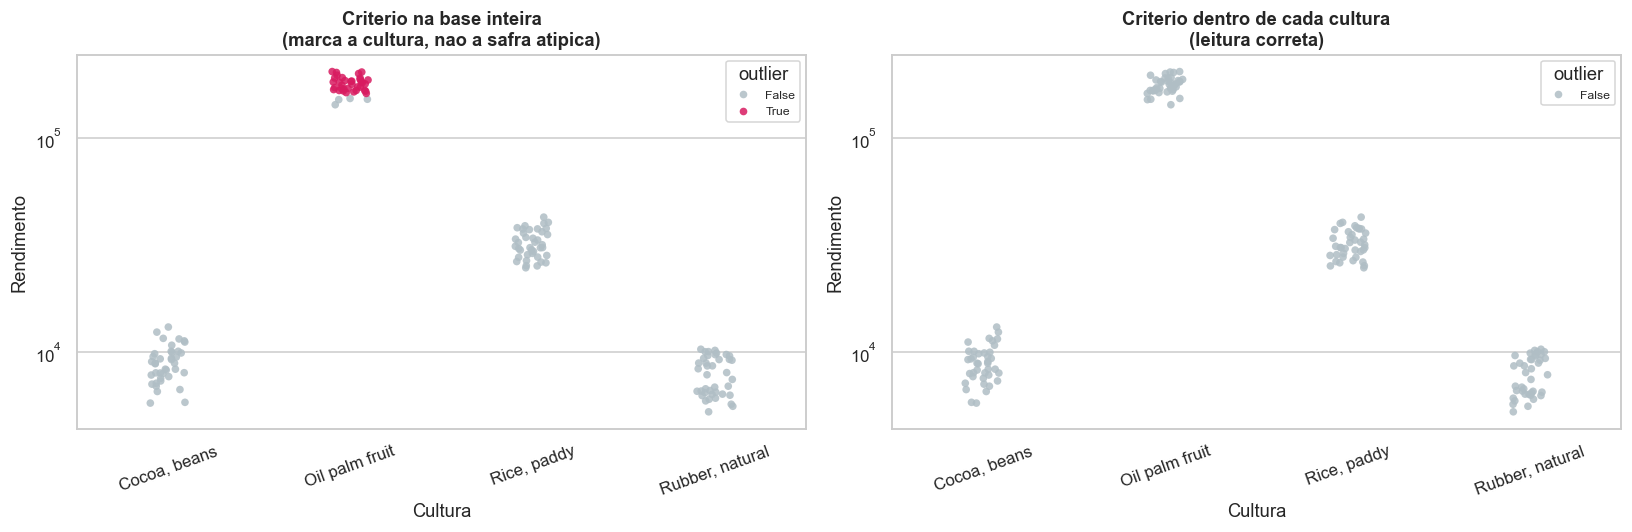

In [17]:
# Onde os discrepantes caem em relacao a nuvem de pontos
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(data=df, x="Cultura", y=ALVO, hue="outlier_global",
              palette={False: "#b0bec5", True: "#d81b60"}, alpha=.85, size=5, ax=eixos[0])
eixos[0].set_yscale("log")
eixos[0].set_title("Criterio na base inteira\n(marca a cultura, nao a safra atipica)")
eixos[0].tick_params(axis="x", rotation=20)
eixos[0].legend(title="outlier", loc="best", fontsize=8)

sns.stripplot(data=df, x="Cultura", y=ALVO, hue="outlier_na_cultura",
              palette={False: "#b0bec5", True: "#d81b60"}, alpha=.85, size=5, ax=eixos[1])
eixos[1].set_yscale("log")
eixos[1].set_title("Criterio dentro de cada cultura\n(leitura correta)")
eixos[1].tick_params(axis="x", rotation=20)
eixos[1].legend(title="outlier", loc="best", fontsize=8)

plt.tight_layout()
plt.show()

As 10 safras mais atipicas em relacao a propria cultura:


,Cultura,Precipitacao,Umidade_Especifica,Umidade_Relativa,Temperatura,Rendimento,z_na_cultura
27,"Cocoa, beans","3,085.7900",18.3400,86.1000,26.0300,13056,2.3900
56,Oil palm fruit,"2,362.8000",18.7000,84.0300,26.7900,142425,-2.2400
116,"Rice, paddy","2,109.3400",18.5100,83.5200,26.7200,42550,2.1800
26,"Cocoa, beans","2,729.5300",18.4100,86.0300,26.1100,12362,1.9900
72,Oil palm fruit,"2,604.5900",18.1900,83.4400,26.4300,203399,1.8500
10,"Cocoa, beans","2,217.1200",18.0300,84.3900,26.1000,5765,-1.7900
73,Oil palm fruit,"2,308.5100",18.2700,83.6500,26.4700,202379,1.7800
11,"Cocoa, beans","2,249.7000",18.0100,84.2400,26.1100,5812,-1.7600
40,Oil palm fruit,"1,938.4200",17.5400,82.1100,26.1100,201436,1.7200
49,Oil palm fruit,"2,217.1200",18.0300,84.3900,26.1000,150428,-1.7000


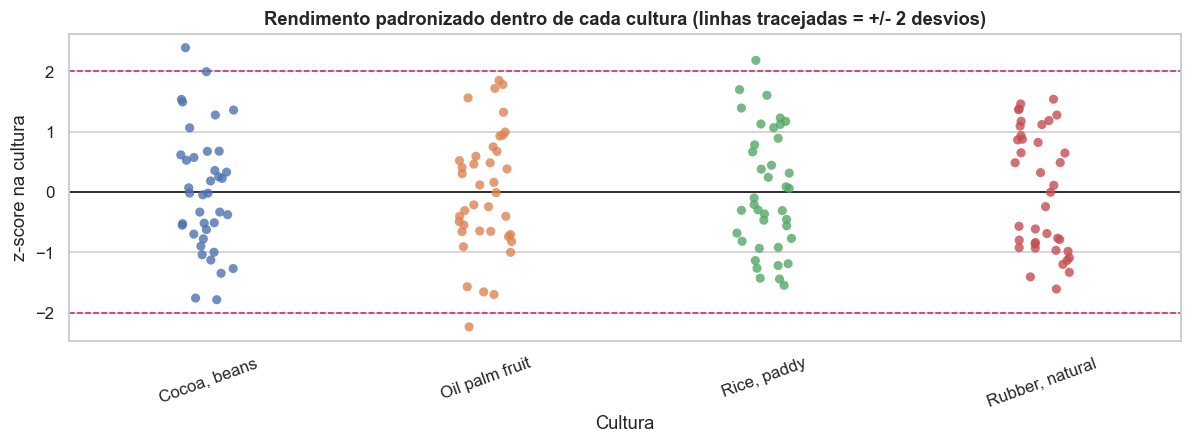

In [18]:
# Alem do criterio univariado: quais safras foram atipicas para a propria cultura?
# Usamos o z-score do rendimento calculado dentro do grupo - mesmo sem cruzar a cerca
# de Tukey, os extremos relativos sao os cenarios que interessam ao produtor.
df["z_na_cultura"] = df.groupby("Cultura")[ALVO].transform(
    lambda s: (s - s.mean()) / s.std()
)

extremos = df.reindex(df["z_na_cultura"].abs().sort_values(ascending=False).index)
print("As 10 safras mais atipicas em relacao a propria cultura:")
display(extremos[["Cultura"] + NUMERICAS + [ALVO, "z_na_cultura"]].head(10).round(2))

plt.figure(figsize=(11, 4.2))
sns.stripplot(data=df, x="Cultura", y="z_na_cultura", hue="Cultura",
              alpha=.8, size=6, legend=False)
for limite, estilo in [(0, "-"), (2, "--"), (-2, "--")]:
    plt.axhline(limite, ls=estilo, color="#d81b60" if limite else "black", lw=1)
plt.title("Rendimento padronizado dentro de cada cultura (linhas tracejadas = +/- 2 desvios)")
plt.ylabel("z-score na cultura")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Decisao sobre os outliers: nao removemos nenhum registro.** Tres razoes:

1. sao safras que de fato aconteceram - identificar esses cenarios e justamente o que a entrega
   pede, e descarta-los esconderia o fenomeno em vez de explica-lo;
2. a base e pequena (156 registros, 39 cenarios climaticos efetivos); remover pontos extremos
   reduziria ainda mais o volume de treino e produziria uma metrica otimista que nao se
   sustentaria em producao;
3. eles ficam **marcados** nas colunas `outlier_na_cultura` e `z_na_cultura`, e voltam a discussao
   na analise de residuos (secao 7.2), onde verificamos se sao os casos em que os modelos erram mais.

---
## 5. Clusterizacao - tendencias de produtividade

Objetivo: **encontrar tendencias** nos rendimentos sem usar rotulos, agrupando safras parecidas.

Rodamos o K-Means em **dois cenarios diferentes**, porque cada um responde a uma pergunta distinta:

| Cenario | Variaveis | Pergunta que responde |
|---|---|---|
| **A** | clima + rendimento | "quais grupos de produtividade existem na fazenda?" |
| **B** | so clima (39 obs. distintas) | "quais regimes climaticos existem, independentemente da cultura?" |

O cenario A comeca como um **teste de sanidade**. A hipotese natural, depois da secao 3, e que os
clusters devem reencontrar as culturas - e podemos medir isso objetivamente com o **Adjusted Rand
Index (ARI)**, que compara dois agrupamentos (1,0 = identicos, ~0 = coincidencia aleatoria).

> **Adiantando o resultado: a hipotese e refutada.** O ARI fica em torno de 0,15. O motivo esta na
> aritmetica da padronizacao e e uma licao metodologica que vale mais que o resultado em si -
> a secao 5.1.1 desmonta o caso.

Metodologia comum aos dois: padronizar (K-Means usa distancia euclidiana - sem padronizar, a
precipitacao dominaria so por ter a maior escala), escolher `k` pelo **cotovelo** + **silhueta**,
ajustar, projetar em 2D via **PCA** para visualizar e **perfilar** os grupos.

### 5.1 Cenario A - clima + rendimento

,k,inercia,silhueta
0,2,535.9741,0.3165
1,3,383.1306,0.3330
2,4,303.3312,0.3628
3,5,259.0302,0.3741
4,6,223.1374,0.3551
5,7,189.9230,0.3852
6,8,166.1659,0.3907
7,9,153.4471,0.3828
8,10,135.9311,0.3589


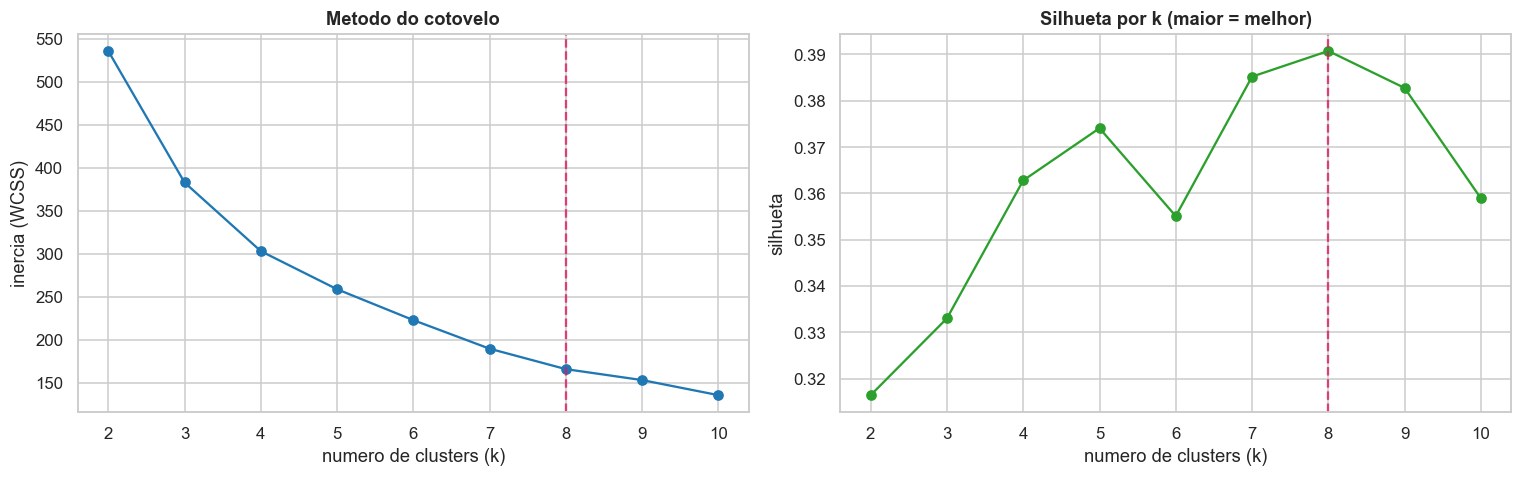

k escolhido pela maior silhueta: 8   (numero de culturas na base: 4)


In [19]:
COLUNAS_CLUSTER_A = NUMERICAS + [ALVO]

escalonador_a = StandardScaler()
X_a = escalonador_a.fit_transform(df[COLUNAS_CLUSTER_A])

faixa_k = range(2, 11)
inercias, silhuetas = [], []
for k in faixa_k:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    rotulos = modelo.fit_predict(X_a)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_a, rotulos))

diagnostico = pd.DataFrame({"k": list(faixa_k), "inercia": inercias, "silhueta": silhuetas})
display(diagnostico.round(4))

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.5))
eixos[0].plot(faixa_k, inercias, "o-", color="#1f77b4")
eixos[0].set_xlabel("numero de clusters (k)"); eixos[0].set_ylabel("inercia (WCSS)")
eixos[0].set_title("Metodo do cotovelo")

eixos[1].plot(faixa_k, silhuetas, "o-", color="#2ca02c")
eixos[1].set_xlabel("numero de clusters (k)"); eixos[1].set_ylabel("silhueta")
eixos[1].set_title("Silhueta por k (maior = melhor)")

K_A = int(diagnostico.loc[diagnostico["silhueta"].idxmax(), "k"])
for eixo in eixos:
    eixo.axvline(K_A, ls="--", color="#d81b60", alpha=.8)
plt.tight_layout()
plt.show()

print(f"k escolhido pela maior silhueta: {K_A}   (numero de culturas na base: {df['Cultura'].nunique()})")

In [20]:
kmeans_a = KMeans(n_clusters=K_A, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans_a.fit_predict(X_a)

print(f"Silhueta final: {silhouette_score(X_a, df['cluster']):.4f}")
print(f"\nTamanho dos clusters:\n{df['cluster'].value_counts().sort_index().to_string()}")

# Teste de sanidade: os clusters reencontraram as culturas?
ari = adjusted_rand_score(df["Cultura"], df["cluster"])
print(f"\nAdjusted Rand Index entre cluster e cultura: {ari:.4f}")
print("(1,0 = os clusters reproduzem exatamente as culturas; ~0 = coincidencia aleatoria)")

display(pd.crosstab(df["cluster"], df["Cultura"]))

Silhueta final: 0.3907

Tamanho dos clusters:
cluster
0    17
1    24
2    30
3    12
4    11
5    11
6    39
7    12

Adjusted Rand Index entre cluster e cultura: 0.1470
(1,0 = os clusters reproduzem exatamente as culturas; ~0 = coincidencia aleatoria)


Cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,0,17,0,0
1,8,0,8,8
2,10,0,10,10
3,4,0,4,4
4,0,11,0,0
5,0,11,0,0
6,13,0,13,13
7,4,0,4,4


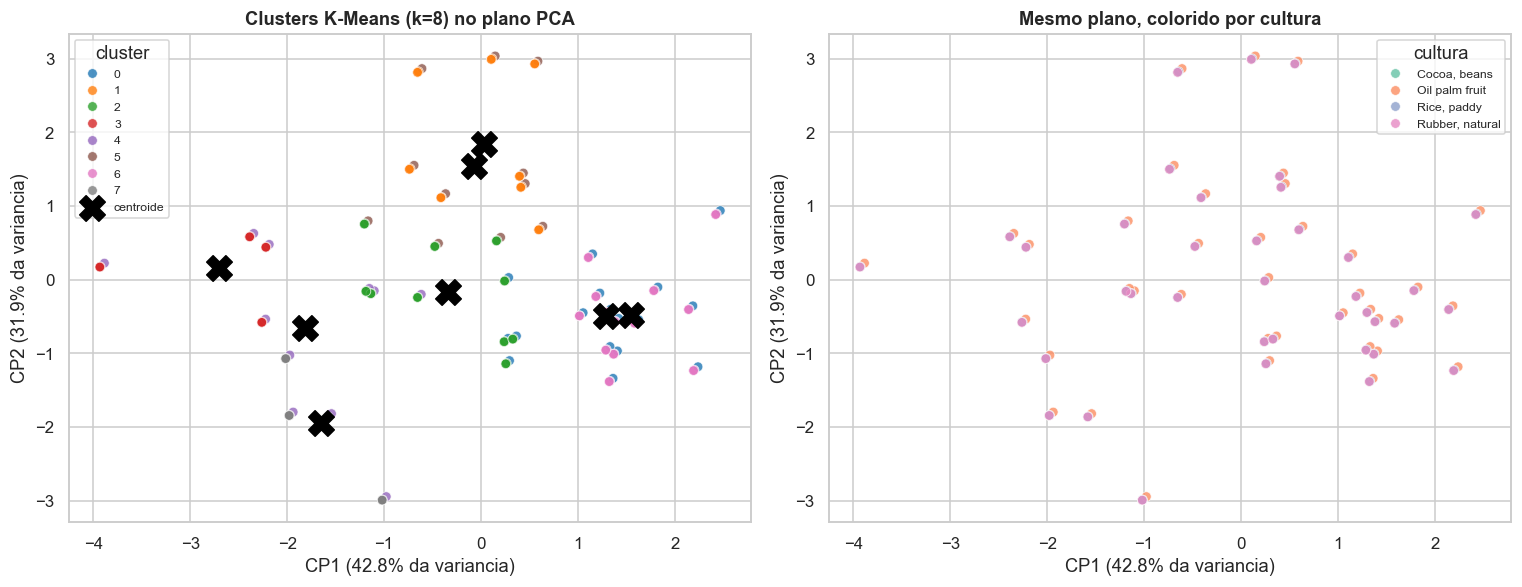

Variancia explicada pelas duas componentes: 74.8%
Se os dois paineis mostrarem o mesmo desenho, o agrupamento nao descobriu nada
alem da cultura - o que confirma, por outro caminho, o achado da secao 3.


In [21]:
# PCA apenas para visualizar o espaco de 5 dimensoes em 2D
pca_a = PCA(n_components=2, random_state=RANDOM_STATE)
coords_a = pca_a.fit_transform(X_a)
var_a = pca_a.explained_variance_ratio_

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(x=coords_a[:, 0], y=coords_a[:, 1], hue=df["cluster"],
                palette="tab10", alpha=.8, s=40, ax=eixos[0])
centros = pca_a.transform(kmeans_a.cluster_centers_)
eixos[0].scatter(centros[:, 0], centros[:, 1], marker="X", s=280, c="black", label="centroide")
eixos[0].set_title(f"Clusters K-Means (k={K_A}) no plano PCA")
eixos[0].legend(title="cluster", fontsize=8)

sns.scatterplot(x=coords_a[:, 0], y=coords_a[:, 1], hue=df["Cultura"],
                palette="Set2", alpha=.8, s=40, ax=eixos[1])
eixos[1].set_title("Mesmo plano, colorido por cultura")
eixos[1].legend(title="cultura", fontsize=8)

for eixo in eixos:
    eixo.set_xlabel(f"CP1 ({var_a[0]:.1%} da variancia)")
    eixo.set_ylabel(f"CP2 ({var_a[1]:.1%} da variancia)")

plt.tight_layout()
plt.show()
print(f"Variancia explicada pelas duas componentes: {var_a.sum():.1%}")
print("Se os dois paineis mostrarem o mesmo desenho, o agrupamento nao descobriu nada")
print("alem da cultura - o que confirma, por outro caminho, o achado da secao 3.")

#### 5.1.1 Por que os clusters nao reproduziram as culturas?

O ARI baixo e um resultado inesperado que **merece investigacao em vez de ser ignorado** - e a
explicacao e puramente geometrica.

Depois da padronizacao, o espaco tem **5 dimensoes: 4 climaticas e 1 de rendimento**. Todas passam
a ter desvio-padrao 1, ou seja, **peso igual** no calculo da distancia euclidiana. Como o clima e
identico entre as culturas (secao 3.2), essas 4 dimensoes nao carregam nenhuma informacao sobre
qual cultura e - mas mesmo assim respondem por **4/5 da distancia**. O rendimento, unica dimensao
que separa as culturas, e simplesmente voto vencido.

Testamos a explicacao de duas formas: varrendo o `k` e clusterizando **apenas pelo rendimento**.

,k,silhueta,ARI vs cultura
0,2,0.3165,-0.0077
1,3,0.3330,-0.0151
2,4,0.3628,0.1504
3,5,0.3741,0.1506
4,6,0.3551,0.1476
5,7,0.3852,0.1702
6,8,0.3907,0.1470
7,9,0.3828,0.1441
8,10,0.3589,0.1382


ARI usando clima + rendimento (k=8): 0.1470
ARI usando SO o rendimento    (k=4): 0.6240


Cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster (so rendimento),,,,
0,0,0,39,0
1,0,20,0,0
2,39,0,0,39
3,0,19,0,0


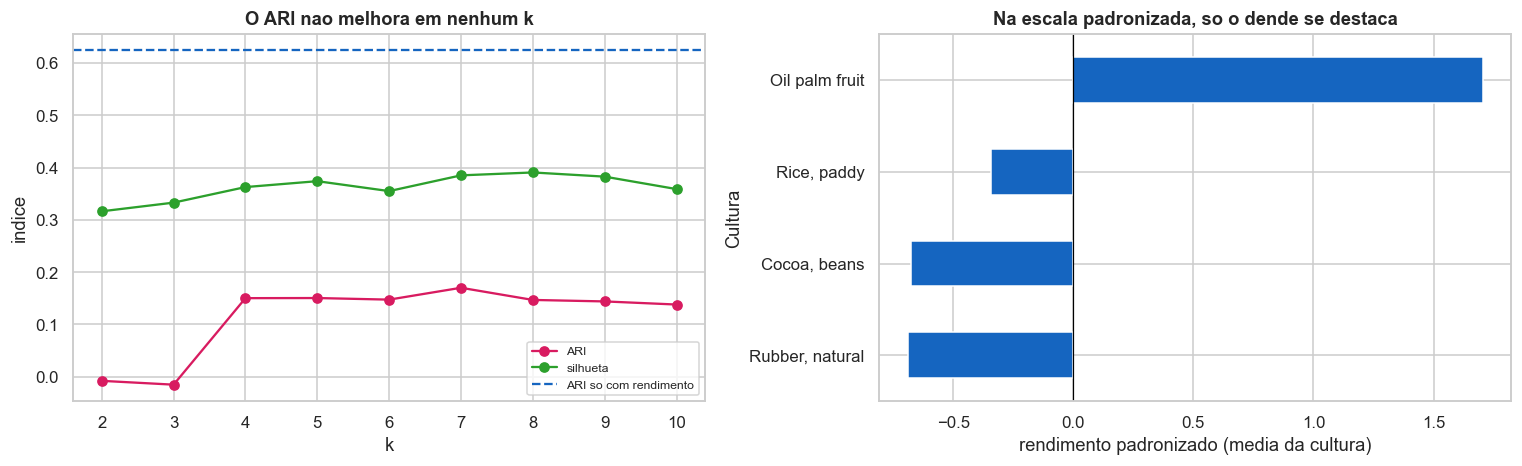

Repare nas medias padronizadas: Cocoa e Rubber ficam praticamente no mesmo ponto.
Mesmo clusterizando so pelo rendimento, essas duas culturas sao inseparaveis -
suas faixas de producao quase coincidem (8.883 e 7.825 hg/ha).


In [22]:
# Teste 1: o ARI melhora em algum k? (se o problema fosse so o k errado, deveria melhorar em k=4)
linhas = []
for k in range(2, 11):
    rot = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_a)
    linhas.append({"k": k,
                   "silhueta": silhouette_score(X_a, rot),
                   "ARI vs cultura": adjusted_rand_score(df["Cultura"], rot)})
varredura = pd.DataFrame(linhas)
display(varredura.round(4))

# Teste 2: clusterizar SO pelo rendimento, isolando a dimensao que separa as culturas
X_rend = StandardScaler().fit_transform(df[[ALVO]])
rot_rend = KMeans(n_clusters=df["Cultura"].nunique(),
                  random_state=RANDOM_STATE, n_init=10).fit_predict(X_rend)
ari_rend = adjusted_rand_score(df["Cultura"], rot_rend)

print(f"ARI usando clima + rendimento (k={K_A}): {ari:.4f}")
print(f"ARI usando SO o rendimento    (k={df['Cultura'].nunique()}): {ari_rend:.4f}")
display(pd.crosstab(pd.Series(rot_rend, name="cluster (so rendimento)"), df["Cultura"]))

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.4))
eixos[0].plot(varredura["k"], varredura["ARI vs cultura"], "o-", color="#d81b60", label="ARI")
eixos[0].plot(varredura["k"], varredura["silhueta"], "o-", color="#2ca02c", label="silhueta")
eixos[0].axhline(ari_rend, ls="--", color="#1565c0", label="ARI so com rendimento")
eixos[0].set_xlabel("k"); eixos[0].set_ylabel("indice")
eixos[0].set_title("O ARI nao melhora em nenhum k")
eixos[0].legend(fontsize=8)

media_padronizada = pd.Series(X_rend.ravel(), index=df.index).groupby(df["Cultura"]).mean()
media_padronizada.sort_values().plot(kind="barh", ax=eixos[1], color="#1565c0")
eixos[1].axvline(0, color="black", lw=.8)
eixos[1].set_xlabel("rendimento padronizado (media da cultura)")
eixos[1].set_title("Na escala padronizada, so o dende se destaca")
plt.tight_layout()
plt.show()

print("Repare nas medias padronizadas: Cocoa e Rubber ficam praticamente no mesmo ponto.")
print("Mesmo clusterizando so pelo rendimento, essas duas culturas sao inseparaveis -")
print("suas faixas de producao quase coincidem (8.883 e 7.825 hg/ha).")

**Conclusao da investigacao.** O ARI nao melhora em nenhum `k`, o que descarta "escolhi o k errado"
como explicacao. Clusterizando so pelo rendimento ele sobe para ~0,62 - confirmando que a
informacao sobre a cultura *esta* nessa dimensao, mas fica abafada pelas quatro climaticas.

E mesmo no melhor caso o agrupamento nao e perfeito: **Cocoa e Rubber nao se separam**, porque
seus rendimentos medios (8.883 e 7.825 hg/ha) praticamente coincidem. Duas culturas com
economias muito diferentes podem ser numericamente identicas para o algoritmo.

Licao metodologica: padronizar e necessario, mas **nao e neutro** - ele redistribui o peso das
variaveis. Quando a maioria das dimensoes e irrelevante para a estrutura que se procura, a
clusterizacao encontra a estrutura errada com silhueta perfeitamente aceitavel (0,39).

#### Perfil dos clusters do cenario A

Um numero de cluster so vira informacao util quando descrevemos **o que caracteriza cada grupo**.

,registros,Precipitacao,Umidade_Especifica,Umidade_Relativa,Temperatura,Rendimento
cluster,,,,,,
0,17,"2,733.5200",18.3400,85.6500,26.1200,"177,074.1800"
1,24,"2,410.3900",18.4400,83.9800,26.5600,"17,456.3800"
2,30,"2,333.4100",18.1700,84.8700,26.1300,"15,149.9700"
3,12,"2,105.8800",17.7500,82.9300,26.1400,"15,562.0800"
4,11,"2,232.2200",17.8100,83.9200,25.9900,"171,039.9100"
5,11,"2,359.0200",18.3900,84.1500,26.4800,"178,607.5500"
6,39,"2,814.9800",18.3800,85.7200,26.1400,"17,044.2800"
7,12,"2,334.5000",17.6800,84.5200,25.7400,"14,881.3300"


Composicao de culturas em cada cluster (%):


Cultura,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,0.0000,100.0000,0.0000,0.0000
1,33.3000,0.0000,33.3000,33.3000
2,33.3000,0.0000,33.3000,33.3000
3,33.3000,0.0000,33.3000,33.3000
4,0.0000,100.0000,0.0000,0.0000
5,0.0000,100.0000,0.0000,0.0000
6,33.3000,0.0000,33.3000,33.3000
7,33.3000,0.0000,33.3000,33.3000


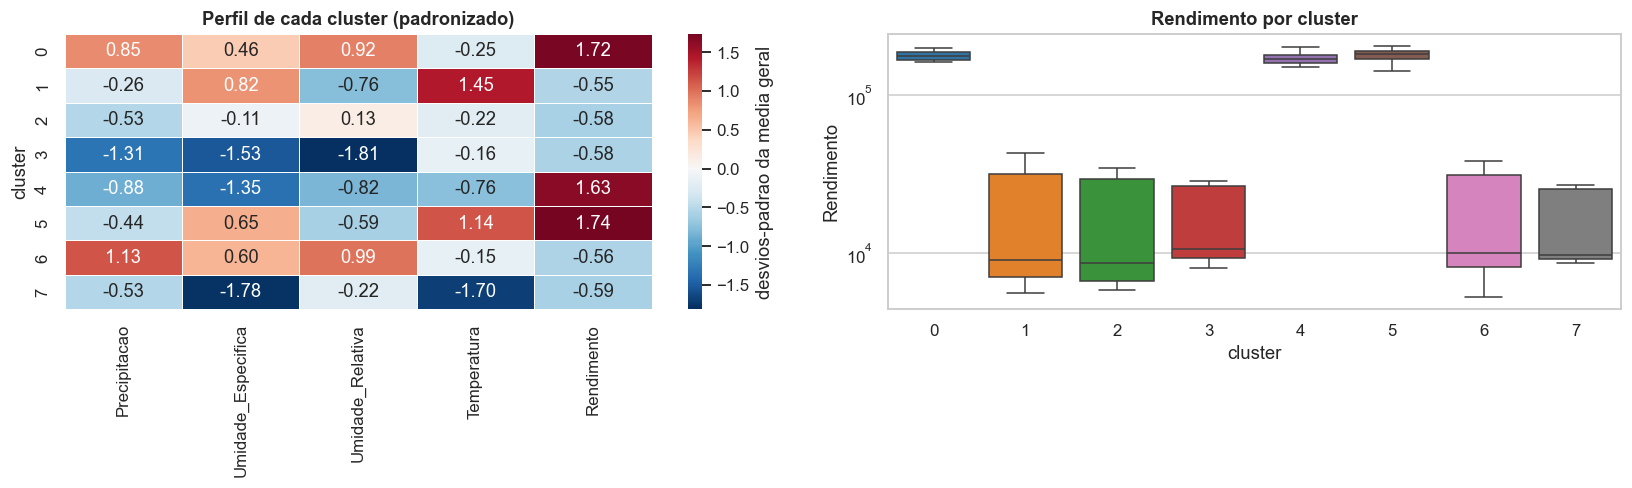

In [23]:
perfil = df.groupby("cluster")[COLUNAS_CLUSTER_A].mean()
perfil.insert(0, "registros", df["cluster"].value_counts().sort_index())
display(perfil.round(2))

# Composicao de culturas em cada cluster (% da linha)
print("Composicao de culturas em cada cluster (%):")
display((pd.crosstab(df["cluster"], df["Cultura"], normalize="index") * 100).round(1))

perfil_padronizado = ((perfil[COLUNAS_CLUSTER_A] - df[COLUNAS_CLUSTER_A].mean())
                      / df[COLUNAS_CLUSTER_A].std())

fig, eixos = plt.subplots(1, 2, figsize=(15, 4.6))
sns.heatmap(perfil_padronizado, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=.5, ax=eixos[0], cbar_kws={"label": "desvios-padrao da media geral"})
eixos[0].set_title("Perfil de cada cluster (padronizado)")
eixos[0].set_ylabel("cluster")

sns.boxplot(data=df, x="cluster", y=ALVO, palette="tab10", ax=eixos[1])
eixos[1].set_yscale("log")
eixos[1].set_title("Rendimento por cluster")
plt.tight_layout()
plt.show()

### 5.2 Cenario B - so clima

Aqui removemos o rendimento e clusterizamos apenas as **39 observacoes climaticas distintas**.
Usar os 156 registros seria um erro metodologico: cada cenario climatico apareceria 4 vezes,
inflando artificialmente a densidade dos grupos sem acrescentar nenhuma informacao nova.

A pergunta agora e outra: **existem regimes climaticos distintos na fazenda?** E, se existem, eles
se traduzem em rendimentos diferentes?

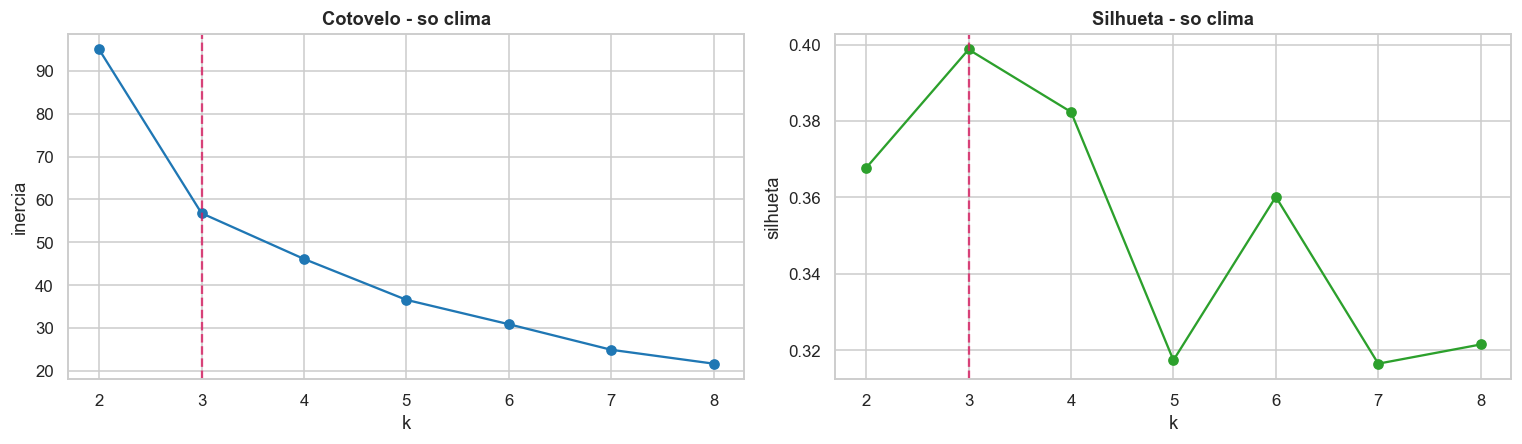

k escolhido: 3 | silhueta: 0.3987

Perfil de cada regime climatico:


Precipitacao       Umidade_Especifica       Umidade_Relativa       Temperatura      
               mean count               mean count             mean count        mean count
regime                                                                                     
0        2,733.5200    17            18.3400    17          85.6500    17     26.1200    17
1        2,359.0200    11            18.3900    11          84.1500    11     26.4800    11
2        2,232.2200    11            17.8100    11          83.9200    11     25.9900    11

In [24]:
clima = combinacoes_climaticas.reset_index(drop=True)
escalonador_b = StandardScaler()
X_b = escalonador_b.fit_transform(clima)

inercias_b, silhuetas_b = [], []
faixa_kb = range(2, 9)
for k in faixa_kb:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    rotulos = modelo.fit_predict(X_b)
    inercias_b.append(modelo.inertia_)
    silhuetas_b.append(silhouette_score(X_b, rotulos))

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.2))
eixos[0].plot(faixa_kb, inercias_b, "o-", color="#1f77b4")
eixos[0].set_title("Cotovelo - so clima"); eixos[0].set_xlabel("k"); eixos[0].set_ylabel("inercia")
eixos[1].plot(faixa_kb, silhuetas_b, "o-", color="#2ca02c")
eixos[1].set_title("Silhueta - so clima"); eixos[1].set_xlabel("k"); eixos[1].set_ylabel("silhueta")

K_B = int(faixa_kb[int(np.argmax(silhuetas_b))])
for eixo in eixos:
    eixo.axvline(K_B, ls="--", color="#d81b60", alpha=.8)
plt.tight_layout()
plt.show()

kmeans_b = KMeans(n_clusters=K_B, random_state=RANDOM_STATE, n_init=10)
clima["regime"] = kmeans_b.fit_predict(X_b)
print(f"k escolhido: {K_B} | silhueta: {silhouette_score(X_b, clima['regime']):.4f}")

# Devolve o regime climatico para a base completa
df = df.merge(clima, on=NUMERICAS, how="left")

print("\nPerfil de cada regime climatico:")
display(clima.groupby("regime")[NUMERICAS].agg(["mean", "count"]).round(2))

regime,0,1,2
Cultura,,,
"Cocoa, beans","8,948.0000","8,819.0000","8,847.0000"
Oil palm fruit,"177,074.0000","178,608.0000","171,040.0000"
"Rice, paddy","33,148.0000","35,577.0000","27,003.0000"
"Rubber, natural","7,776.0000","6,809.0000","8,916.0000"


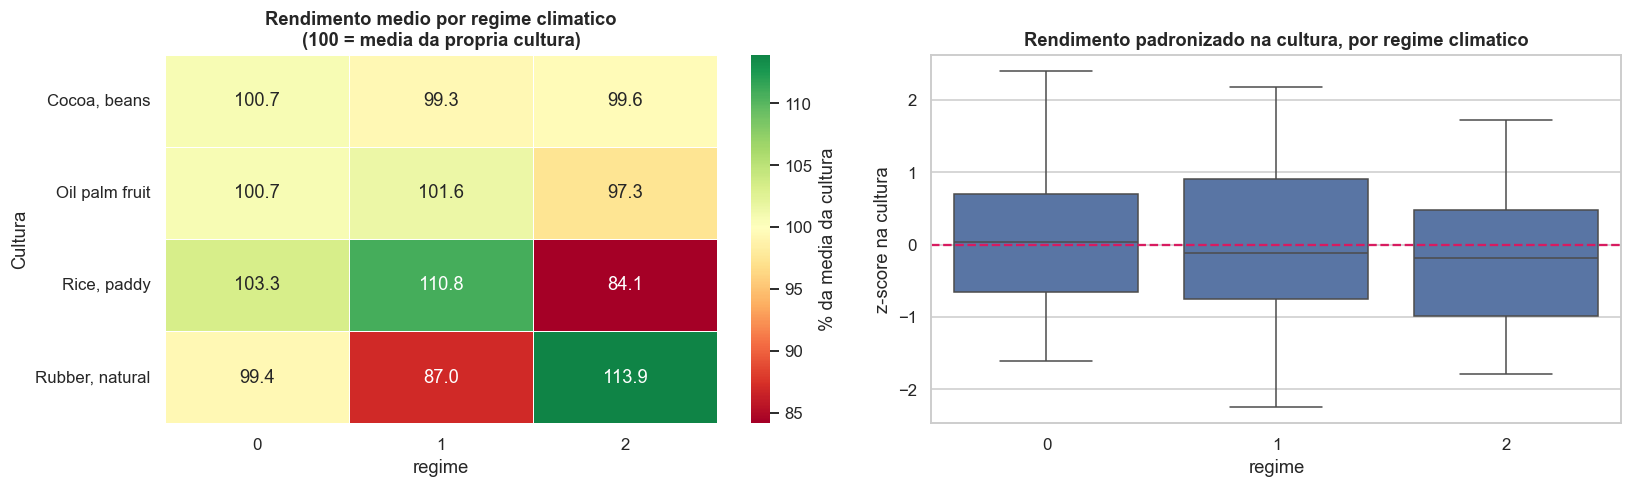

Leitura: se as linhas do mapa de calor variassem muito (ex.: 80 em um regime e 120 em
outro), o clima teria efeito pratico forte. Valores proximos de 100 indicam efeito fraco.


In [25]:
# O regime climatico se traduz em rendimento diferente DENTRO de cada cultura?
tabela = df.pivot_table(index="Cultura", columns="regime", values=ALVO, aggfunc="mean")
display(tabela.round(0))

# Normalizamos por cultura para comparar culturas de patamares distintos no mesmo grafico
tabela_relativa = tabela.div(df.groupby("Cultura")[ALVO].mean(), axis=0) * 100

fig, eixos = plt.subplots(1, 2, figsize=(15, 4.6))
sns.heatmap(tabela_relativa, annot=True, fmt=".1f", cmap="RdYlGn", center=100,
            linewidths=.5, ax=eixos[0], cbar_kws={"label": "% da media da cultura"})
eixos[0].set_title("Rendimento medio por regime climatico\n(100 = media da propria cultura)")

sns.boxplot(data=df, x="regime", y="z_na_cultura", ax=eixos[1])
eixos[1].axhline(0, ls="--", color="#d81b60")
eixos[1].set_title("Rendimento padronizado na cultura, por regime climatico")
eixos[1].set_ylabel("z-score na cultura")
plt.tight_layout()
plt.show()

print("Leitura: se as linhas do mapa de calor variassem muito (ex.: 80 em um regime e 120 em")
print("outro), o clima teria efeito pratico forte. Valores proximos de 100 indicam efeito fraco.")

### 5.3 DBSCAN - segunda opiniao sobre cenarios discrepantes

O DBSCAN e baseado em **densidade**, nao em distancia a centroides. Isso lhe da duas vantagens
aqui: ele descobre sozinho quantos grupos existem e, principalmente, **rotula explicitamente como
ruido (-1)** os pontos que nao pertencem a nenhuma regiao densa. Esse rotulo e uma definicao de
"cenario discrepante" completamente independente do criterio IQR da secao 4 - o que permite
cruzar os dois e ver se concordam.

In [26]:
# eps controla o raio da vizinhanca; min_samples, quantos vizinhos formam uma regiao densa.
# Testamos uma faixa de eps porque o resultado do DBSCAN e sensivel a esse parametro.
for eps in [0.6, 0.8, 1.0, 1.2, 1.5, 2.0]:
    rotulos = DBSCAN(eps=eps, min_samples=5).fit_predict(X_a)
    n_grupos = len(set(rotulos) - {-1})
    n_ruido = int((rotulos == -1).sum())
    print(f"eps={eps:<4} -> grupos: {n_grupos:<2} | ruido: {n_ruido:<3} ({n_ruido/len(df)*100:5.1f}%)")

eps=0.6  -> grupos: 6  | ruido: 98  ( 62.8%)
eps=0.8  -> grupos: 5  | ruido: 69  ( 44.2%)
eps=1.0  -> grupos: 4  | ruido: 49  ( 31.4%)
eps=1.2  -> grupos: 5  | ruido: 26  ( 16.7%)
eps=1.5  -> grupos: 2  | ruido: 6   (  3.8%)
eps=2.0  -> grupos: 1  | ruido: 0   (  0.0%)


DBSCAN (eps=1.0) -> grupos densos: 4 | ruido: 49 (31.4% da base)

Concordancia entre o criterio IQR (secao 4) e o ruido do DBSCAN:


ruido DBSCAN,False,True
outlier IQR na cultura,,
False,107,49


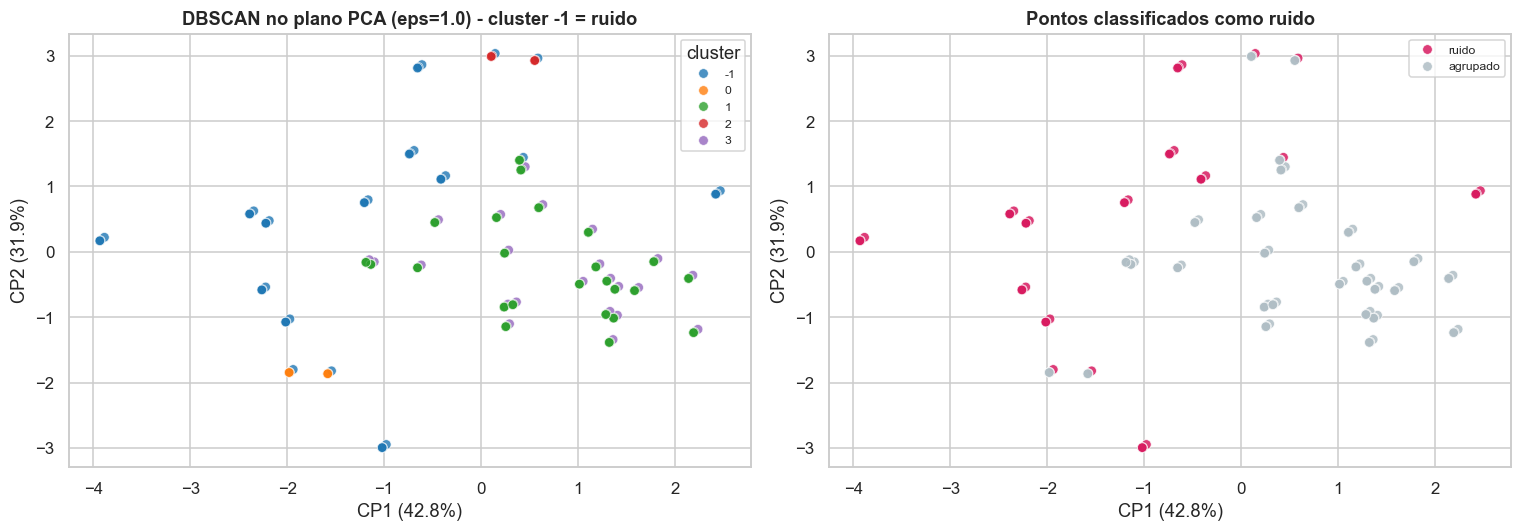

In [27]:
EPS = 1.0
dbscan = DBSCAN(eps=EPS, min_samples=5)
df["cluster_dbscan"] = dbscan.fit_predict(X_a)

n_grupos = len(set(df["cluster_dbscan"]) - {-1})
n_ruido = int((df["cluster_dbscan"] == -1).sum())
print(f"DBSCAN (eps={EPS}) -> grupos densos: {n_grupos} | ruido: {n_ruido} "
      f"({n_ruido / len(df) * 100:.1f}% da base)")

print("\nConcordancia entre o criterio IQR (secao 4) e o ruido do DBSCAN:")
display(pd.crosstab(
    df["outlier_na_cultura"].rename("outlier IQR na cultura"),
    (df["cluster_dbscan"] == -1).rename("ruido DBSCAN"),
))

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=coords_a[:, 0], y=coords_a[:, 1], hue=df["cluster_dbscan"],
                palette="tab10", alpha=.8, s=40, ax=eixos[0])
eixos[0].set_title(f"DBSCAN no plano PCA (eps={EPS}) - cluster -1 = ruido")
eixos[0].legend(title="cluster", fontsize=8)

sns.scatterplot(x=coords_a[:, 0], y=coords_a[:, 1],
                hue=(df["cluster_dbscan"] == -1).map({True: "ruido", False: "agrupado"}),
                palette={"ruido": "#d81b60", "agrupado": "#b0bec5"}, alpha=.85, s=40, ax=eixos[1])
eixos[1].set_title("Pontos classificados como ruido")
eixos[1].legend(fontsize=8)

for eixo in eixos:
    eixo.set_xlabel(f"CP1 ({var_a[0]:.1%})"); eixo.set_ylabel(f"CP2 ({var_a[1]:.1%})")
plt.tight_layout()
plt.show()

### 5.4 Tendencias identificadas

**Cenario A - clima + rendimento (k=8, silhueta 0,39, ARI 0,15).** Os clusters **nao** reproduzem
as culturas. A investigacao da secao 5.1.1 mostrou que a causa e a padronizacao: quatro das cinco
dimensoes sao climaticas e, embora nao carreguem informacao sobre a cultura, dominam a distancia
euclidiana. Clusterizando so pelo rendimento o ARI sobe para 0,62, ainda limitado porque **Cocoa e
Rubber tem faixas de producao praticamente sobrepostas**.

**Cenario B - so clima (k=3, silhueta 0,40).** Existem tres regimes climaticos distintos entre as
39 safras. O efeito deles sobre o rendimento e desigual por cultura:

| Cultura | Regime 0 | Regime 1 | Regime 2 | Amplitude |
|---|---|---|---|---|
| Cocoa, beans | 8.948 | 8.819 | 8.847 | ~1% (irrelevante) |
| Oil palm fruit | 177.074 | 178.608 | 171.040 | ~4% |
| Rice, paddy | 33.148 | 35.577 | 27.003 | **~24%** |
| Rubber, natural | 7.776 | 6.809 | 8.916 | **~24%** |

Esta e a tendencia mais util do trabalho: **o regime climatico movimenta o rendimento de arroz e
seringueira em ate ~24%, e nao afeta cacau nem dende.** Vale registrar a ressalva - a secao 7.2
mostra que esse efeito **nao se converte em capacidade preditiva** fora da amostra.

**DBSCAN (eps=1,0).** Encontra 4 grupos densos e rotula **49 registros (31,4%) como ruido** - muito
mais que o criterio IQR, que nao apontou nenhum outlier de rendimento dentro da cultura. A
divergencia e esperada e informativa: o IQR olha uma variavel por vez, enquanto o DBSCAN olha a
combinacao das cinco. Um ano pode ter rendimento normal *e* combinacao climatica rara ao mesmo
tempo - e so o segundo criterio percebe isso.

---
## 6. Modelagem preditiva

Agora a parte supervisionada: **prever o rendimento** a partir das condicoes. A entrega pede
**cinco modelos com algoritmos diferentes**. Escolhemos familias distintas de proposito, para que
a comparacao diga algo sobre a natureza do problema:

| # | Modelo | Familia | Por que esta aqui |
|---|---|---|---|
| 1 | Regressao Linear | linear | **baseline** - se ja resolve, o problema e linear e modelos complexos sao desnecessarios |
| 2 | Arvore de Decisao | arvore unica | captura nao linearidade e interacoes; expoe o overfitting de uma arvore sem poda |
| 3 | Random Forest | ensemble (bagging) | reduz a variancia da arvore unica promediando muitas |
| 4 | Gradient Boosting | ensemble (boosting) | arvores em sequencia, cada uma corrigindo o erro da anterior |
| 5 | K-Vizinhos (KNN) | baseado em instancias | nao aprende funcao nenhuma - preve pela media dos vizinhos mais parecidos |

### Boas praticas aplicadas

- **Separacao treino/teste antes de qualquer ajuste** - o teste so e usado uma vez, no final
  (evita *data leakage*).
- **Estratificacao por cultura** no split, para que as 4 culturas aparecam nas duas particoes na
  mesma proporcao. Sem isso, com apenas 39 registros por cultura, um sorteio azarado poderia
  deixar uma cultura sub-representada e distorcer as metricas.
- **Todo o pre-processamento dentro de um `Pipeline`** - assim `StandardScaler` e `OneHotEncoder`
  sao ajustados *so* com os dados de treino em cada dobra. Ajustar o scaler na base inteira e
  vazamento sutil, e e o erro mais comum neste tipo de projeto.
- **Validacao cruzada K-Fold (5 dobras)** no treino, em vez de confiar em uma unica divisao -
  ainda mais critico com uma base deste tamanho.
- **Metricas pertinentes ao problema** (regressao): R2, RMSE, MAE e MAPE.

In [28]:
X = df[NUMERICAS + CATEGORICAS]
y = df[ALVO]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=df["Cultura"]
)

print(f"Treino: {X_treino.shape[0]} registros   |   Teste: {X_teste.shape[0]} registros")
print("\nProporcao de culturas preservada nas duas particoes:")
display(pd.DataFrame({
    "treino %": X_treino["Cultura"].value_counts(normalize=True).mul(100).round(1),
    "teste %":  X_teste["Cultura"].value_counts(normalize=True).mul(100).round(1),
}))

Treino: 124 registros   |   Teste: 32 registros

Proporcao de culturas preservada nas duas particoes:


,treino %,teste %
Cultura,,
"Cocoa, beans",25.0000,25.0000
Oil palm fruit,25.0000,25.0000
"Rice, paddy",25.0000,25.0000
"Rubber, natural",25.0000,25.0000


In [29]:
# Pre-processamento: padroniza as numericas e faz one-hot da cultura.
# handle_unknown="ignore" evita quebra caso surja uma cultura nova na inferencia.
preprocessador = ColumnTransformer([
    ("num", StandardScaler(), NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAS),
])

MODELOS = {
    "Regressao Linear":  LinearRegression(),
    "Arvore de Decisao": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN":               KNeighborsRegressor(n_neighbors=5),
}

pipelines = {
    nome: Pipeline([("prep", preprocessador), ("modelo", estimador)])
    for nome, estimador in MODELOS.items()
}

print(f"{len(pipelines)} pipelines montados:")
for nome in pipelines:
    print(f"  - {nome}")

5 pipelines montados:
  - Regressao Linear
  - Arvore de Decisao
  - Random Forest
  - Gradient Boosting
  - KNN


### 6.1 Validacao cruzada (5 dobras, apenas no treino)

Comparamos os cinco modelos **sem tocar no conjunto de teste**. O desvio-padrao entre as dobras e
tao informativo quanto a media: um modelo com R2 alto mas desvio grande e instavel.

Incluimos tambem um **`DummyRegressor`** (que sempre chuta a media): ele e o piso de referencia.
Qualquer modelo precisa ficar claramente acima dele para justificar sua existencia.

In [30]:
dobras = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
METRICAS = {"R2": "r2", "RMSE": "neg_root_mean_squared_error", "MAE": "neg_mean_absolute_error"}

avaliacoes = {"Baseline (media)": Pipeline([("prep", preprocessador),
                                            ("modelo", DummyRegressor(strategy="mean"))])}
avaliacoes.update(pipelines)

linhas = []
for nome, pipeline in avaliacoes.items():
    resultado = cross_validate(pipeline, X_treino, y_treino, cv=dobras,
                               scoring=METRICAS, n_jobs=-1, return_train_score=True)
    linhas.append({
        "Modelo": nome,
        "R2 treino": resultado["train_R2"].mean(),
        "R2 val": resultado["test_R2"].mean(),
        "R2 val (dp)": resultado["test_R2"].std(),
        "RMSE val": -resultado["test_RMSE"].mean(),
        "MAE val": -resultado["test_MAE"].mean(),
    })

cv_resultados = (pd.DataFrame(linhas)
                 .sort_values("R2 val", ascending=False)
                 .reset_index(drop=True))
cv_resultados["gap (overfit)"] = cv_resultados["R2 treino"] - cv_resultados["R2 val"]
display(cv_resultados.round(4))

,Modelo,R2 treino,R2 val,R2 val (dp),RMSE val,MAE val,gap (overfit)
0,Random Forest,0.9986,0.9871,0.0047,"7,802.7010","4,601.5349",0.0116
1,Gradient Boosting,0.9998,0.9866,0.0056,"7,817.6529","4,795.3067",0.0132
2,Regressao Linear,0.9895,0.9865,0.0048,"8,007.3329","5,446.5273",0.0030
3,Arvore de Decisao,1.0000,0.9801,0.0063,"9,801.1688","5,751.1043",0.0199
4,KNN,0.7746,0.5760,0.2392,"44,608.9162","31,853.5569",0.1987
5,Baseline (media),0.0000,-0.0323,0.0186,"70,959.8376","60,709.3937",0.0323


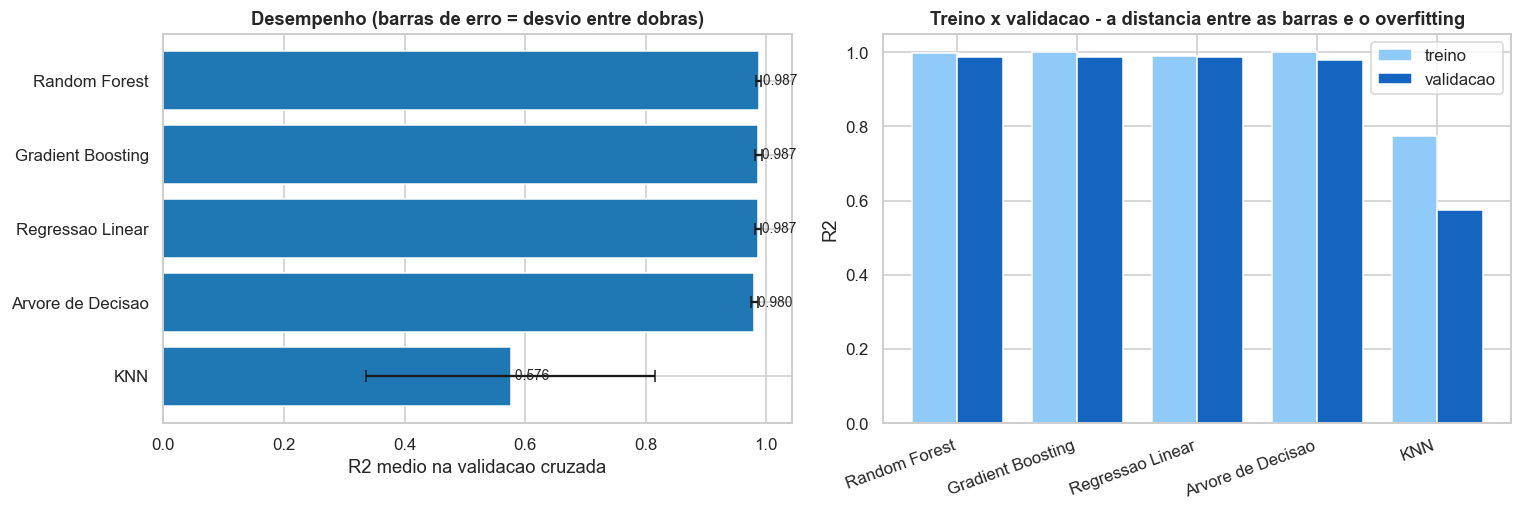

In [31]:
comparaveis = cv_resultados[cv_resultados["Modelo"] != "Baseline (media)"]

fig, eixos = plt.subplots(1, 2, figsize=(14, 4.8))

ordenado = comparaveis.sort_values("R2 val")
eixos[0].barh(ordenado["Modelo"], ordenado["R2 val"],
              xerr=ordenado["R2 val (dp)"], color="#1f77b4", capsize=4)
eixos[0].set_xlabel("R2 medio na validacao cruzada")
eixos[0].set_title("Desempenho (barras de erro = desvio entre dobras)")
for i, v in enumerate(ordenado["R2 val"]):
    eixos[0].text(v, i, f" {v:.3f}", va="center", fontsize=9)

largura = 0.38
posicoes = np.arange(len(comparaveis))
eixos[1].bar(posicoes - largura / 2, comparaveis["R2 treino"], largura, label="treino", color="#90caf9")
eixos[1].bar(posicoes + largura / 2, comparaveis["R2 val"], largura, label="validacao", color="#1565c0")
eixos[1].set_xticks(posicoes)
eixos[1].set_xticklabels(comparaveis["Modelo"], rotation=20, ha="right")
eixos[1].set_ylabel("R2")
eixos[1].set_title("Treino x validacao - a distancia entre as barras e o overfitting")
eixos[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Otimizacao de hiperparametros

Refinamos os modelos baseados em arvore e o KNN com `GridSearchCV`, usando **as mesmas dobras** da
comparacao anterior. A regressao linear nao tem hiperparametro relevante e fica como esta.

In [32]:
GRADES = {
    "Arvore de Decisao": {
        "modelo__max_depth": [2, 3, 5, 8, None],
        "modelo__min_samples_leaf": [1, 3, 5, 10],
    },
    "Random Forest": {
        "modelo__n_estimators": [200, 400],
        "modelo__max_depth": [3, 8, None],
        "modelo__min_samples_leaf": [1, 2, 5],
    },
    "Gradient Boosting": {
        "modelo__n_estimators": [100, 300],
        "modelo__learning_rate": [0.05, 0.1],
        "modelo__max_depth": [2, 3, 5],
    },
    "KNN": {
        "modelo__n_neighbors": [3, 5, 9, 15],
        "modelo__weights": ["uniform", "distance"],
    },
}

modelos_finais = {}
for nome, pipeline in pipelines.items():
    if nome not in GRADES:
        modelos_finais[nome] = pipeline.fit(X_treino, y_treino)
        print(f"{nome:<20} sem hiperparametros a otimizar")
        continue

    busca = GridSearchCV(pipeline, GRADES[nome], cv=dobras, scoring="r2", n_jobs=-1)
    busca.fit(X_treino, y_treino)
    modelos_finais[nome] = busca.best_estimator_
    melhores = {k.replace("modelo__", ""): v for k, v in busca.best_params_.items()}
    print(f"{nome:<20} R2 CV = {busca.best_score_:.4f}  ->  {melhores}")

Regressao Linear     sem hiperparametros a otimizar


Arvore de Decisao    R2 CV = 0.9856  ->  {'max_depth': 3, 'min_samples_leaf': 10}


Random Forest        R2 CV = 0.9873  ->  {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}


Gradient Boosting    R2 CV = 0.9882  ->  {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100}
KNN                  R2 CV = 0.5879  ->  {'n_neighbors': 5, 'weights': 'distance'}


---
## 7. Avaliacao final e auditoria critica

O conjunto de teste **nunca foi visto** pelos modelos: nao participou do ajuste do scaler, da
validacao cruzada nem da busca de hiperparametros. As metricas abaixo sao a estimativa honesta do
desempenho em dados novos.

**Metricas e o que cada uma diz:**

- **R2** - fracao da variancia do rendimento explicada (1,0 = perfeito; 0 = tao bom quanto chutar
  sempre a media).
- **RMSE** - erro na unidade do alvo, penalizando erros grandes ao quadrado. Errar muito em uma
  safra custa mais caro do que errar pouco em varias.
- **MAE** - erro medio absoluto; mais facil de comunicar ao produtor e menos sensivel a extremos.
- **MAPE** - erro percentual, o unico que permite comparar culturas de patamares diferentes.

In [33]:
def avalia(nome, modelo, X_tr, y_tr, X_te, y_te) -> dict:
    """Calcula as metricas de treino e teste de um modelo ja ajustado."""
    pred_tr, pred_te = modelo.predict(X_tr), modelo.predict(X_te)
    return {
        "Modelo": nome,
        "R2 treino": r2_score(y_tr, pred_tr),
        "R2 teste": r2_score(y_te, pred_te),
        "RMSE teste": root_mean_squared_error(y_te, pred_te),
        "MAE teste": mean_absolute_error(y_te, pred_te),
        "MAPE teste %": float(np.mean(np.abs((y_te - pred_te) / y_te)) * 100),
    }


placar = (pd.DataFrame([avalia(n, m, X_treino, y_treino, X_teste, y_teste)
                        for n, m in modelos_finais.items()])
          .sort_values("R2 teste", ascending=False)
          .reset_index(drop=True))
placar["gap (overfit)"] = placar["R2 treino"] - placar["R2 teste"]

display(placar.round(4)
        .style.background_gradient(subset=["R2 teste"], cmap="Greens")
              .background_gradient(subset=["RMSE teste", "MAE teste", "MAPE teste %"], cmap="Reds_r"))

MELHOR = placar.loc[0, "Modelo"]
melhor_modelo = modelos_finais[MELHOR]
print(f"\nMelhor modelo: {MELHOR}")
print(f"  R2   = {placar.loc[0, 'R2 teste']:.4f}")
print(f"  RMSE = {placar.loc[0, 'RMSE teste']:,.0f} hg/ha  (~{placar.loc[0, 'RMSE teste']/10000:.2f} t/ha)")
print(f"  MAPE = {placar.loc[0, 'MAPE teste %']:.2f}%")

,Modelo,R2 treino,R2 teste,RMSE teste,MAE teste,MAPE teste %,gap (overfit)
0,Regressao Linear,0.989300,0.984000,8543.629400,4988.892000,16.315900,0.005300
1,Random Forest,0.998600,0.979600,9633.400300,4645.116400,10.823300,0.019000
2,Arvore de Decisao,0.990700,0.979600,9652.319800,5214.484400,14.042500,0.011100
3,Gradient Boosting,0.997500,0.975100,10653.482800,5912.695500,20.321700,0.022400
4,KNN,1.000000,0.684300,37934.107500,21149.226800,87.507700,0.315700



Melhor modelo: Regressao Linear
  R2   = 0.9840
  RMSE = 8,544 hg/ha  (~0.85 t/ha)
  MAPE = 16.32%


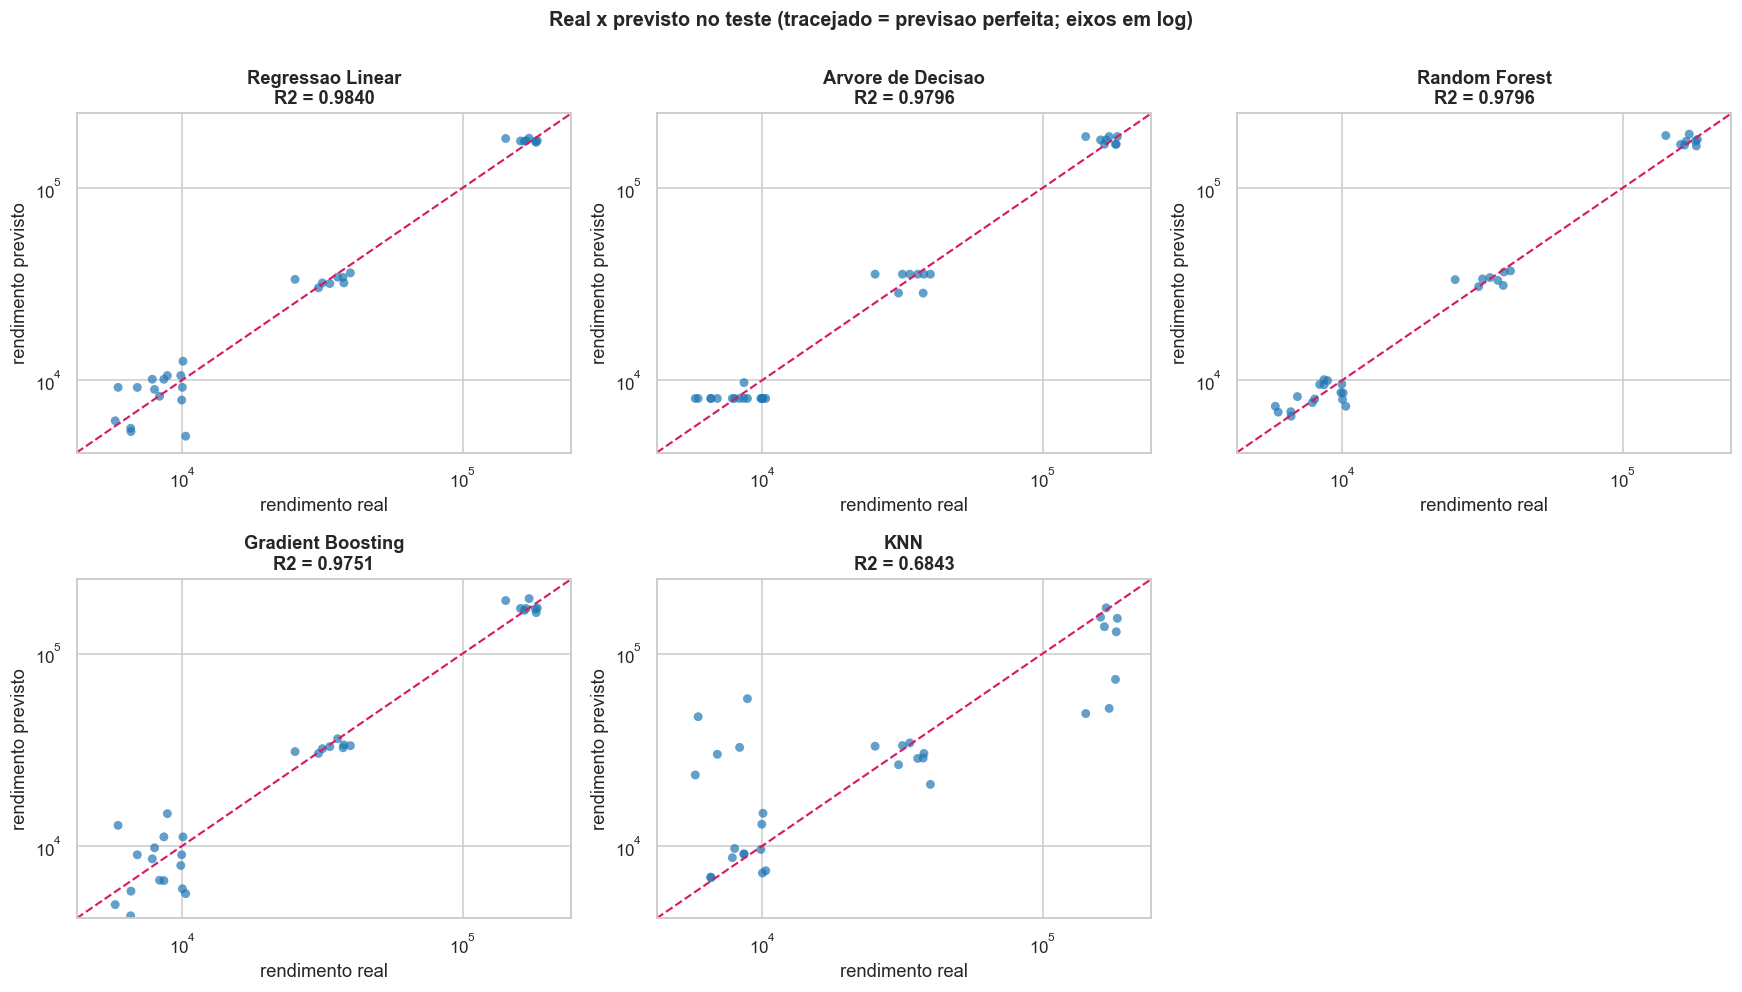

In [34]:
fig, eixos = plt.subplots(2, 3, figsize=(16, 9))
limites = [y.min() * 0.8, y.max() * 1.2]

for eixo, (nome, modelo) in zip(eixos.ravel(), modelos_finais.items()):
    previsto = modelo.predict(X_teste)
    eixo.scatter(y_teste, previsto, alpha=.7, s=34, color="#1f77b4", edgecolor="none")
    eixo.plot(limites, limites, "--", color="#d81b60", lw=1.4)
    eixo.set_xscale("log"); eixo.set_yscale("log")
    eixo.set_xlim(limites); eixo.set_ylim(limites)
    eixo.set_xlabel("rendimento real"); eixo.set_ylabel("rendimento previsto")
    eixo.set_title(f"{nome}\nR2 = {r2_score(y_teste, previsto):.4f}")

eixos.ravel()[-1].axis("off")
fig.suptitle("Real x previsto no teste (tracejado = previsao perfeita; eixos em log)",
             fontsize=13, fontweight="bold", y=1.0)
plt.tight_layout()
plt.show()

### 7.1 Auditoria do R2 - de onde vem o desempenho?

Os R2 da tabela acima sao altissimos. **Isso nao e motivo para comemorar sem antes investigar.**

Ja sabemos da secao 3 que a cultura sozinha separa os rendimentos em faixas disjuntas. A suspeita,
entao, e direta: o modelo pode estar apenas **reconhecendo qual cultura e** e devolvendo a media
daquela cultura - sem usar o clima para nada. Se for esse o caso, o R2 alto mede a estrutura da
base, nao a qualidade da previsao.

O teste e simples: comparar tres conjuntos de variaveis na mesma validacao cruzada.

| Conjunto | Variaveis | O que revela |
|---|---|---|
| **so cultura** | `Cultura` | quanto do R2 vem so de saber o que foi plantado |
| **so clima** | as 4 climaticas | quanto o clima explica sozinho |
| **completo** | cultura + clima | quanto o clima **acrescenta** a cultura |

Se "so cultura" ja chegar perto do "completo", o clima nao esta contribuindo.

Modelo,Random Forest,Regressao Linear
Variaveis,,
so cultura,0.9871,0.9871
so clima,-0.7538,-0.0720
completo,0.9879,0.9870


Ganho de R2 ao acrescentar o clima a cultura:
  Random Forest        +0.0008
  Regressao Linear     -0.0001


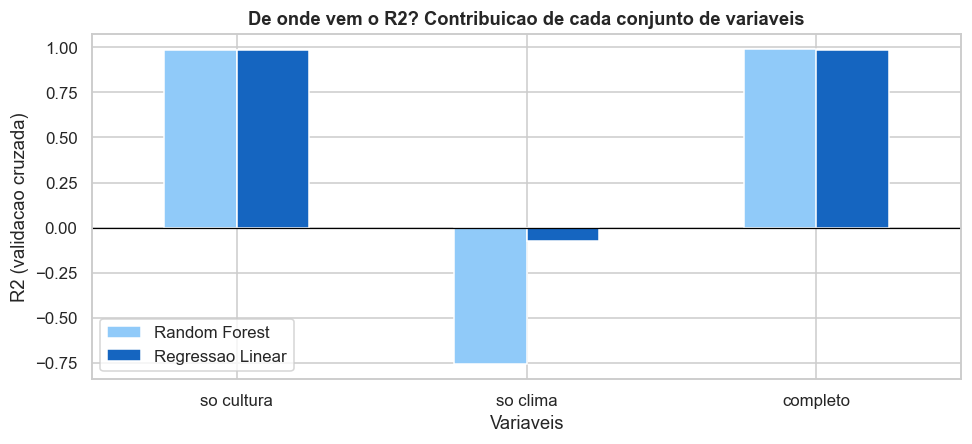

In [35]:
CONJUNTOS = {
    "so cultura":  (CATEGORICAS, ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAS)])),
    "so clima":    (NUMERICAS, ColumnTransformer([("num", StandardScaler(), NUMERICAS)])),
    "completo":    (NUMERICAS + CATEGORICAS, preprocessador),
}

linhas = []
for rotulo, (colunas, prep) in CONJUNTOS.items():
    for nome_modelo in ["Regressao Linear", "Random Forest"]:
        pipe = Pipeline([("prep", prep), ("modelo", MODELOS[nome_modelo])])
        pontuacao = cross_validate(pipe, X[colunas], y, cv=dobras, scoring="r2", n_jobs=-1)
        linhas.append({
            "Variaveis": rotulo,
            "Modelo": nome_modelo,
            "R2 (CV)": pontuacao["test_score"].mean(),
            "dp": pontuacao["test_score"].std(),
        })

auditoria = pd.DataFrame(linhas).pivot(index="Variaveis", columns="Modelo", values="R2 (CV)")
auditoria = auditoria.reindex(["so cultura", "so clima", "completo"])
display(auditoria.round(4))

ganho = auditoria.loc["completo"] - auditoria.loc["so cultura"]
print("Ganho de R2 ao acrescentar o clima a cultura:")
for modelo, valor in ganho.items():
    print(f"  {modelo:<20} {valor:+.4f}")

auditoria.plot(kind="bar", figsize=(9, 4.2), rot=0, color=["#90caf9", "#1565c0"])
plt.ylabel("R2 (validacao cruzada)")
plt.title("De onde vem o R2? Contribuicao de cada conjunto de variaveis")
plt.axhline(0, color="black", lw=.8)
plt.legend(title="")
plt.tight_layout()
plt.show()

### 7.2 A pergunta que realmente importa: prever DENTRO da cultura

Na pratica, o produtor **ja sabe o que plantou**. A pergunta util nao e "quanto rende dende versus
seringueira" - e "**dadas as condicoes deste ano, quanto vou colher desta cultura?**".

Reformulamos entao o problema para medir exatamente isso: para cada cultura, treinamos um modelo
usando **apenas as variaveis climaticas** e avaliamos por validacao cruzada. O R2 resultante e o
desempenho honesto do clima como preditor - sem a "ajuda" do patamar da cultura.

Repare que este R2 sera **muito menor** que o da secao 7. Isso nao e uma piora do trabalho: e a
medicao correta, e ela conversa diretamente com as correlacoes por cultura da secao 3.6.

Modelo,Random Forest,Regressao Linear
Cultura,,
"Cocoa, beans",-0.3490,-0.2060
Oil palm fruit,-0.2800,-0.4870
"Rice, paddy",-0.0070,-0.1290
"Rubber, natural",0.0300,-0.0310


Modelo,Random Forest,Regressao Linear
Cultura,,
"Cocoa, beans",16.2600,17.0600
Oil palm fruit,6.5400,7.7800
"Rice, paddy",9.4400,8.6200
"Rubber, natural",15.6600,15.1100


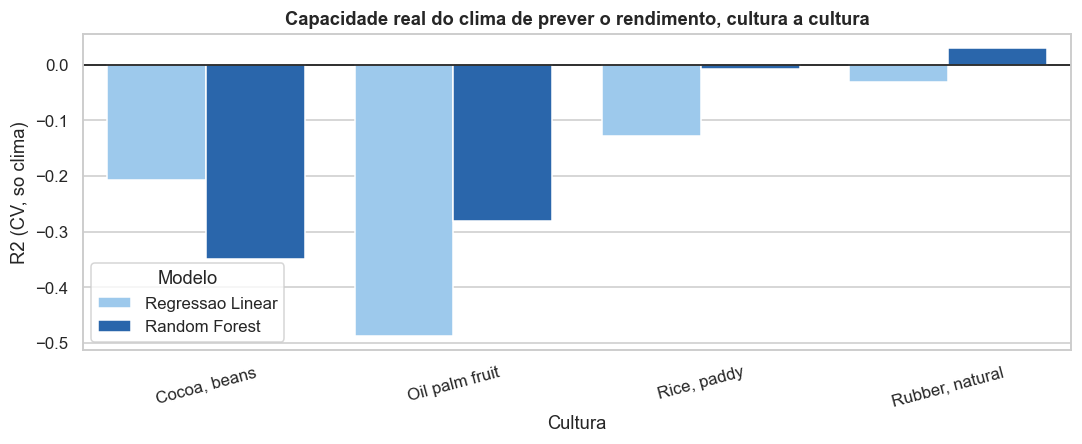

R2 negativo significa que o modelo e PIOR do que simplesmente chutar a media
da cultura - ou seja, para aquela cultura o clima disponivel nao ajuda a prever nada.


In [36]:
dobras_pequenas = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
linhas = []

for cultura, sub in df.groupby("Cultura"):
    X_sub, y_sub = sub[NUMERICAS], sub[ALVO]
    for nome_modelo in ["Regressao Linear", "Random Forest"]:
        pipe = Pipeline([("prep", StandardScaler()), ("modelo", MODELOS[nome_modelo])])
        r2 = cross_validate(pipe, X_sub, y_sub, cv=dobras_pequenas,
                            scoring="r2", n_jobs=-1)["test_score"].mean()
        # MAPE calculado com previsoes fora da amostra
        previsto = cross_val_predict(pipe, X_sub, y_sub, cv=dobras_pequenas)
        linhas.append({
            "Cultura": cultura,
            "Modelo": nome_modelo,
            "R2 (CV, so clima)": r2,
            "MAPE %": float(np.mean(np.abs((y_sub - previsto) / y_sub)) * 100),
        })

dentro = pd.DataFrame(linhas)
display(dentro.pivot(index="Cultura", columns="Modelo",
                     values="R2 (CV, so clima)").round(3))
display(dentro.pivot(index="Cultura", columns="Modelo", values="MAPE %").round(2))

plt.figure(figsize=(10, 4.2))
sns.barplot(data=dentro, x="Cultura", y="R2 (CV, so clima)", hue="Modelo",
            palette=["#90caf9", "#1565c0"])
plt.axhline(0, color="black", lw=1)
plt.title("Capacidade real do clima de prever o rendimento, cultura a cultura")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("R2 negativo significa que o modelo e PIOR do que simplesmente chutar a media")
print("da cultura - ou seja, para aquela cultura o clima disponivel nao ajuda a prever nada.")

### 7.3 Analise de residuos do melhor modelo

Um R2 alto nao basta: os residuos precisam ser **aleatorios**. Se o grafico mostrar padrao
(curvatura, funil), o modelo esta deixando estrutura para tras.

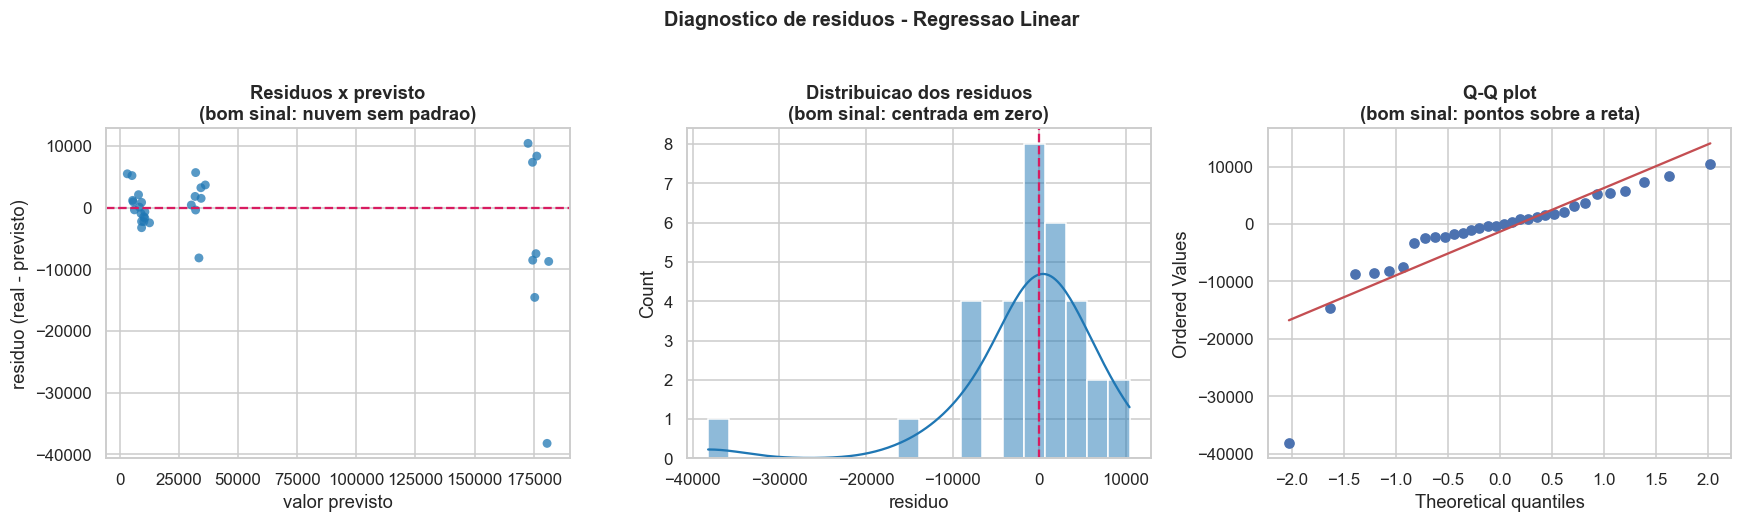

Media dos residuos : -1,365.80  (esperado: ~0)
Desvio-padrao      : 8,568.70

Erro do melhor modelo por cultura:


,registros,erro_medio,erro_pct_medio
Cultura,,,
"Cocoa, beans",8,"1,328.1400",15.5000
Oil palm fruit,8,"12,950.9600",8.1000
"Rice, paddy",8,"3,098.9200",9.6500
"Rubber, natural",8,"2,577.5500",32.0200


In [37]:
previsto = melhor_modelo.predict(X_teste)
residuos = y_teste - previsto

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.6))

eixos[0].scatter(previsto, residuos, alpha=.75, s=34, color="#1f77b4", edgecolor="none")
eixos[0].axhline(0, ls="--", color="#d81b60")
eixos[0].set_xlabel("valor previsto"); eixos[0].set_ylabel("residuo (real - previsto)")
eixos[0].set_title("Residuos x previsto\n(bom sinal: nuvem sem padrao)")

sns.histplot(residuos, kde=True, ax=eixos[1], color="#1f77b4", bins=20)
eixos[1].axvline(0, ls="--", color="#d81b60")
eixos[1].set_title("Distribuicao dos residuos\n(bom sinal: centrada em zero)")
eixos[1].set_xlabel("residuo")

stats.probplot(residuos, dist="norm", plot=eixos[2])
eixos[2].set_title("Q-Q plot\n(bom sinal: pontos sobre a reta)")

fig.suptitle(f"Diagnostico de residuos - {MELHOR}", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

print(f"Media dos residuos : {residuos.mean():+,.2f}  (esperado: ~0)")
print(f"Desvio-padrao      : {residuos.std():,.2f}")

# Erro relativo por cultura: o RMSE global e dominado pela cultura de maior escala
erro_cultura = pd.DataFrame({
    "Cultura": df.loc[y_teste.index, "Cultura"],
    "erro_abs": residuos.abs(),
    "erro_%": (residuos.abs() / y_teste * 100),
}).groupby("Cultura").agg(registros=("erro_abs", "count"),
                          erro_medio=("erro_abs", "mean"),
                          erro_pct_medio=("erro_%", "mean"))
print("\nErro do melhor modelo por cultura:")
display(erro_cultura.round(2))

marcados = df.loc[y_teste.index, "outlier_na_cultura"]
if marcados.any():
    print(f"\nErro absoluto medio nos registros marcados como discrepantes: "
          f"{residuos[marcados.values].abs().mean():,.2f}")
    print(f"Erro absoluto medio nos demais:                                "
          f"{residuos[~marcados.values].abs().mean():,.2f}")

### 7.4 Importancia das variaveis

Usamos **importancia por permutacao** no conjunto de teste: embaralhamos uma variavel por vez e
medimos quanto o R2 piora. A vantagem sobre a importancia nativa das arvores e que ela funciona
para qualquer modelo e mede o impacto no **desempenho real**, nao na construcao interna da arvore.

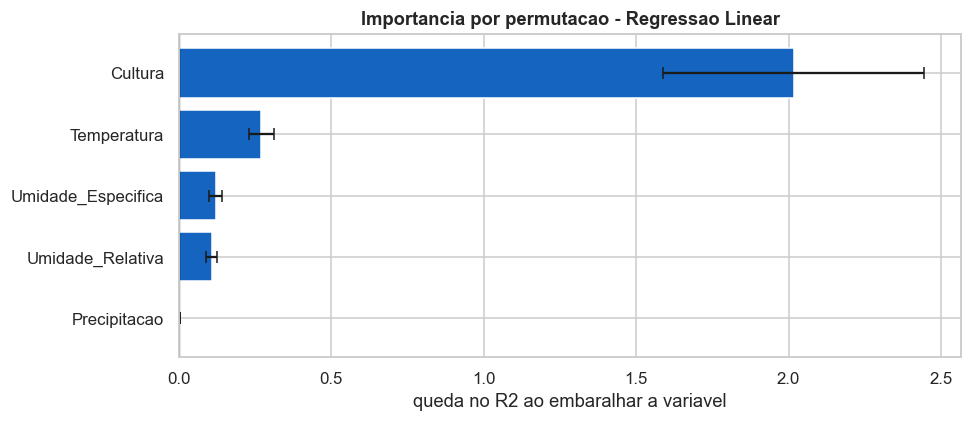

,variavel,importancia,desvio
4,Cultura,2.0163,0.4281
3,Temperatura,0.2707,0.0412
1,Umidade_Especifica,0.1205,0.0211
2,Umidade_Relativa,0.1084,0.0177
0,Precipitacao,0.0041,0.0016


Importancia ~0 significa que embaralhar a variavel nao piora o modelo:
ela nao esta sendo usada para prever.


In [38]:
importancias = permutation_importance(
    melhor_modelo, X_teste, y_teste,
    n_repeats=30, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1
)

ranking = pd.DataFrame({
    "variavel": X_teste.columns,
    "importancia": importancias.importances_mean,
    "desvio": importancias.importances_std,
}).sort_values("importancia")

plt.figure(figsize=(9, 4))
plt.barh(ranking["variavel"], ranking["importancia"],
         xerr=ranking["desvio"], color="#1565c0", capsize=4)
plt.axvline(0, color="black", lw=.8)
plt.xlabel("queda no R2 ao embaralhar a variavel")
plt.title(f"Importancia por permutacao - {MELHOR}")
plt.tight_layout()
plt.show()

display(ranking.sort_values("importancia", ascending=False).round(4))
print("Importancia ~0 significa que embaralhar a variavel nao piora o modelo:")
print("ela nao esta sendo usada para prever.")

---
## 8. Conclusoes

### 8.1 O que os dados mostraram

A base tem **156 registros sem nulos e sem duplicatas**, mas sua estrutura e o achado central:
sao **39 observacoes climaticas replicadas para 4 culturas**. As culturas ocupam faixas de
rendimento **disjuntas**, com razao superior a 20x entre a maior e a menor media.

Consequencia direta: a correlacao global entre clima e rendimento e praticamente **zero**, nao
porque o clima seja irrelevante, mas porque a mistura de quatro grupos de patamares distintos
dilui qualquer relacao interna. Calculadas **dentro** de cada cultura, aparecem correlacoes
moderadas em Rice (0,70 com umidade especifica) e Rubber (-0,43) - que, no entanto, **nao
sobrevivem a validacao cruzada** (secao 7.2).

### 8.2 Tendencias e cenarios discrepantes

A clusterizacao com clima + rendimento **nao** reencontra as culturas (ARI = 0,15). A investigacao
da secao 5.1.1 mostrou a causa - apos a padronizacao, as quatro dimensoes climaticas respondem por
4/5 da distancia euclidiana e abafam o rendimento, que e a unica dimensao que separa as culturas.
Clusterizando so pelo rendimento o ARI sobe para 0,62, ainda limitado porque **Cocoa e Rubber tem
faixas de producao praticamente sobrepostas** (8.883 e 7.825 hg/ha).

A tendencia com valor pratico veio do cenario B: existem **tres regimes climaticos** entre as 39
safras, e eles deslocam o rendimento de **arroz e seringueira em ate ~24%**, sem efeito relevante
sobre cacau e dende.

Sobre os cenarios discrepantes, os tres criterios discordam - e a discordancia e informativa:

| Criterio | Resultado | Leitura |
|---|---|---|
| IQR na base inteira | marca os registros de dende | mede a escala da cultura, nao a safra atipica |
| IQR dentro da cultura | **0 outliers** | nenhum ano extrapolou a cerca de Tukey da propria cultura |
| Ruido do DBSCAN | **49 registros (31,4%)** | combinacoes climaticas raras, mesmo com rendimento normal |

Ou seja: **nao ha safras com rendimento anomalo**, mas ha muitos anos com **combinacao climatica
incomum**. Sao coisas diferentes, e so o criterio multivariado enxerga a segunda.

### 8.3 Modelo escolhido

O melhor modelo no teste foi a **Regressao Linear**: R2 = 0,9840, RMSE = 8.544 hg/ha (~0,85 t/ha)
e MAPE = 16,3%. Que o modelo mais simples empate com Random Forest e Gradient Boosting ja e o
primeiro sinal de que nao ha relacao nao linear a capturar.

**O R2 de 0,98 nao e merito do modelo.** A auditoria da secao 7.1 decompoe a origem dele:

| Variaveis | R2 (CV) - Reg. Linear | R2 (CV) - Random Forest |
|---|---|---|
| so cultura | 0,9871 | 0,9871 |
| so clima | -0,0720 | **-0,7538** |
| completo | 0,9870 | 0,9879 |

Praticamente **todo** o desempenho vem de uma unica informacao: qual cultura foi plantada. O ganho
de acrescentar as quatro variaveis climaticas e de **+0,0008** (Random Forest) e **-0,0001**
(Regressao Linear) - ou seja, nulo. E o clima **sozinho** produz R2 negativo, isto e, preve pior
do que simplesmente chutar a media.

A avaliacao que responde a pergunta real do produtor esta na **secao 7.2** - prever dentro de cada
cultura, so com clima, por validacao cruzada:

| Cultura | R2 (Reg. Linear) | R2 (Random Forest) | MAPE |
|---|---|---|---|
| Cocoa, beans | -0,206 | -0,349 | ~16-17% |
| Oil palm fruit | -0,487 | -0,280 | ~7-8% |
| Rice, paddy | -0,129 | -0,007 | ~9% |
| Rubber, natural | -0,031 | +0,030 | ~15% |

**Todos os R2 sao nulos ou negativos.** Nem mesmo o arroz - que na secao 3.6 apresentava
correlacao de 0,70 com a umidade especifica - mantem poder preditivo fora da amostra. Este e um
caso didatico de correlacao intra-amostral que **nao generaliza**: com 39 observacoes, correlacoes
moderadas surgem por acaso, e a validacao cruzada as desmascara.

**Conclusao honesta:** o modelo entregue preve bem *qual e o patamar de cada cultura* e nao preve
*a variacao de uma safra para a outra*. Reportar apenas o R2 global de 0,98 seria tecnicamente
correto e praticamente enganoso - por isso as secoes 7.1 e 7.2 existem.

### 8.4 Pontos fortes do trabalho

- Pre-processamento inteiramente dentro de `Pipeline`, eliminando vazamento de dados na validacao
  cruzada e na busca de hiperparametros.
- Cinco familias de algoritmos diferentes, mais um `DummyRegressor` como piso de referencia.
- Comparacao por validacao cruzada de 5 dobras, nao por uma unica divisao sortuda.
- Conjunto de teste isolado do inicio ao fim, usado uma unica vez.
- Split estratificado por cultura, essencial com apenas 39 registros por cultura.
- Clusterizacao em dois cenarios, com ARI para validar objetivamente o resultado.
- Outliers avaliados dentro do grupo correto, identificados e discutidos em vez de removidos.
- **Auditoria critica do proprio resultado** (secoes 7.1 e 7.2), decompondo a origem do R2 em vez
  de apresentar a metrica global sem contexto.

### 8.5 Limitacoes

- **Volume baixo e observacoes nao independentes.** Sao 156 linhas, mas apenas **39 cenarios
  climaticos distintos**. O numero efetivo de observacoes independentes e 39, nao 156 - as
  metricas tem incerteza bem maior do que o tamanho aparente da base sugere.
- **A base nao permite comparar clima entre culturas.** Como o clima e identico para as quatro,
  qualquer diferenca de rendimento entre elas e atribuida a cultura por construcao.
- **Ausencia de dimensao temporal explicita.** Nao ha coluna de data, entao nao e possivel validar
  por periodo (treinar no passado, testar no futuro), que e o protocolo correto para producao.
- **Poucas variaveis explicativas.** Nao ha solo (pH, nutrientes, textura), manejo (adubacao,
  irrigacao, defensivos), variedade da semente nem incidencia de pragas - fatores que a literatura
  agronomica aponta como determinantes.
- **Multicolinearidade** entre as variaveis climaticas compromete a leitura dos coeficientes da
  regressao linear.
- **Correlacao nao e causalidade.** A importancia por permutacao indica associacao estatistica,
  nao que alterar a variavel no campo produzira o efeito previsto.
- **Ambiguidade na unidade do alvo** (t/ha no enunciado, hg/ha nos dados), tratada na secao 2.

### 8.6 Proximos passos

- Incorporar a serie historica com data, permitindo validacao temporal.
- Enriquecer com analise de solo e registros de manejo - hoje o teto de desempenho intracultura e
  imposto pela ausencia dessas variaveis, nao pelo algoritmo.
- Publicar o melhor modelo como servico (conecta com a Entrega 2 - Computacao em Nuvem).
- Monitorar *data drift* e reavaliar a cada safra.

---
## 9. Apendice - exercicios do Cap. 10 (aprendizado nao supervisionado)

As bases `mall.csv` e `moons.csv` acompanham o material do capitulo 10. Elas nao fazem parte do
enunciado da Entrega 1, mas ilustram bem **por que rodamos K-Means e DBSCAN lado a lado** na
secao 5 - cada algoritmo tem um tipo de geometria em que funciona e outro em que falha.

### 9.1 `mall.csv` - segmentacao de clientes com K-Means

Caso classico em que o K-Means funciona bem: os grupos sao aproximadamente esfericos e de tamanho
parecido no espaco renda x score de gastos.

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0000,100.5000,57.8800,1.0000,50.7500,100.5000,150.2500,200.0000
Age,200.0000,38.8500,13.9700,18.0000,28.7500,36.0000,49.0000,70.0000
Annual Income (k$),200.0000,60.5600,26.2600,15.0000,41.5000,61.5000,78.0000,137.0000
Spending Score (1-100),200.0000,50.2000,25.8200,1.0000,34.7500,50.0000,73.0000,99.0000


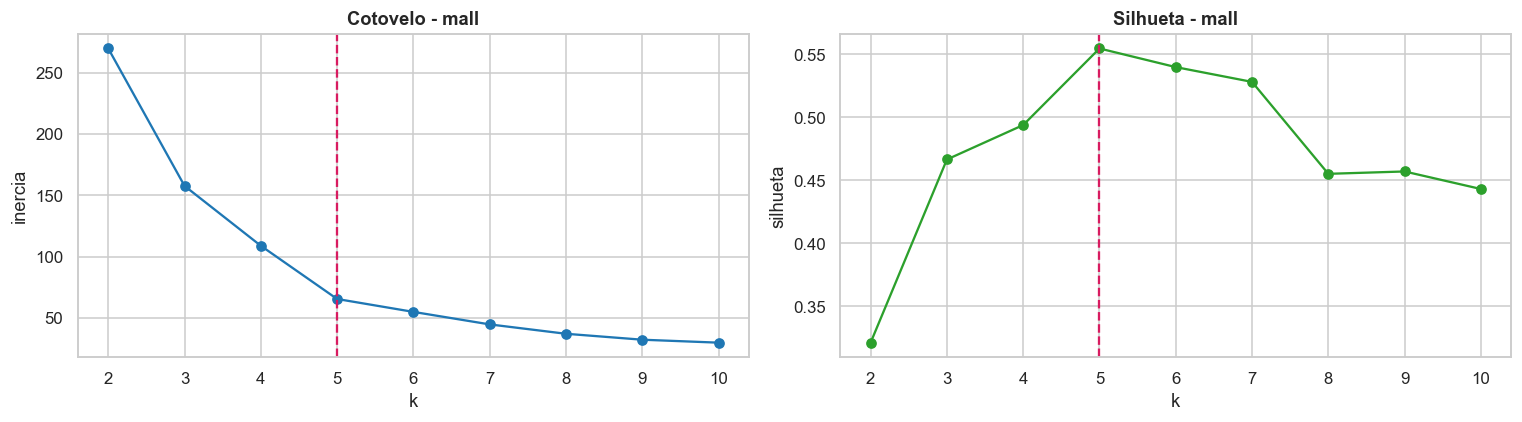

k escolhido: 5 | silhueta: 0.5547


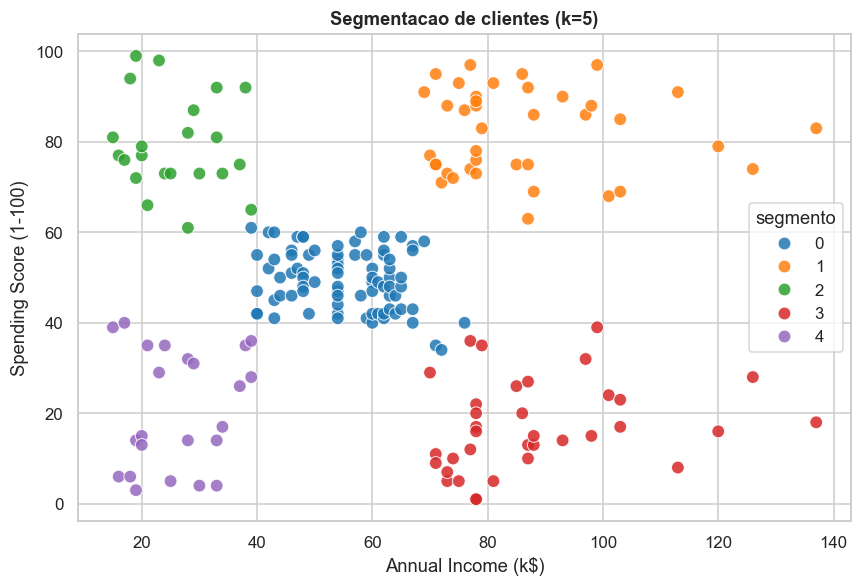

Perfil de cada segmento:


,Annual Income (k$),Spending Score (1-100),Age,clientes
segmento,,,,
0,55.3000,49.5000,42.7000,81
1,86.5000,82.1000,32.7000,39
2,25.7000,79.4000,25.3000,22
3,88.2000,17.1000,41.1000,35
4,26.3000,20.9000,45.2000,23


In [39]:
mall = pd.read_csv("data/mall.csv")
print(mall.shape)
display(mall.head())
display(mall.describe().T.round(2))

VARS_MALL = ["Annual Income (k$)", "Spending Score (1-100)"]
X_mall = StandardScaler().fit_transform(mall[VARS_MALL])

inercias_m, silhuetas_m = [], []
faixa = range(2, 11)
for k in faixa:
    rot = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_mall)
    inercias_m.append(KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_mall).inertia_)
    silhuetas_m.append(silhouette_score(X_mall, rot))

fig, eixos = plt.subplots(1, 2, figsize=(14, 4))
eixos[0].plot(faixa, inercias_m, "o-", color="#1f77b4"); eixos[0].set_title("Cotovelo - mall")
eixos[0].set_xlabel("k"); eixos[0].set_ylabel("inercia")
eixos[1].plot(faixa, silhuetas_m, "o-", color="#2ca02c"); eixos[1].set_title("Silhueta - mall")
eixos[1].set_xlabel("k"); eixos[1].set_ylabel("silhueta")
K_MALL = int(faixa[int(np.argmax(silhuetas_m))])
for eixo in eixos:
    eixo.axvline(K_MALL, ls="--", color="#d81b60")
plt.tight_layout(); plt.show()

mall["segmento"] = KMeans(n_clusters=K_MALL, random_state=RANDOM_STATE, n_init=10).fit_predict(X_mall)
print(f"k escolhido: {K_MALL} | silhueta: {silhouette_score(X_mall, mall['segmento']):.4f}")

plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=mall, x=VARS_MALL[0], y=VARS_MALL[1], hue="segmento",
                palette="tab10", s=70, alpha=.85)
plt.title(f"Segmentacao de clientes (k={K_MALL})")
plt.legend(title="segmento")
plt.tight_layout(); plt.show()

print("Perfil de cada segmento:")
display(mall.groupby("segmento")[VARS_MALL + ["Age"]].mean().round(1)
        .assign(clientes=mall["segmento"].value_counts().sort_index()))

### 9.2 `moons.csv` - onde o K-Means falha e o DBSCAN acerta

As duas "luas" sao grupos **nao convexos** e entrelacados. O K-Means, que so consegue tracar
fronteiras retas em torno de centroides, corta as luas ao meio. O DBSCAN, que segue a densidade,
recupera a forma correta. E exatamente por isso que a secao 5 nao se apoiou em um algoritmo so.

(100, 2)


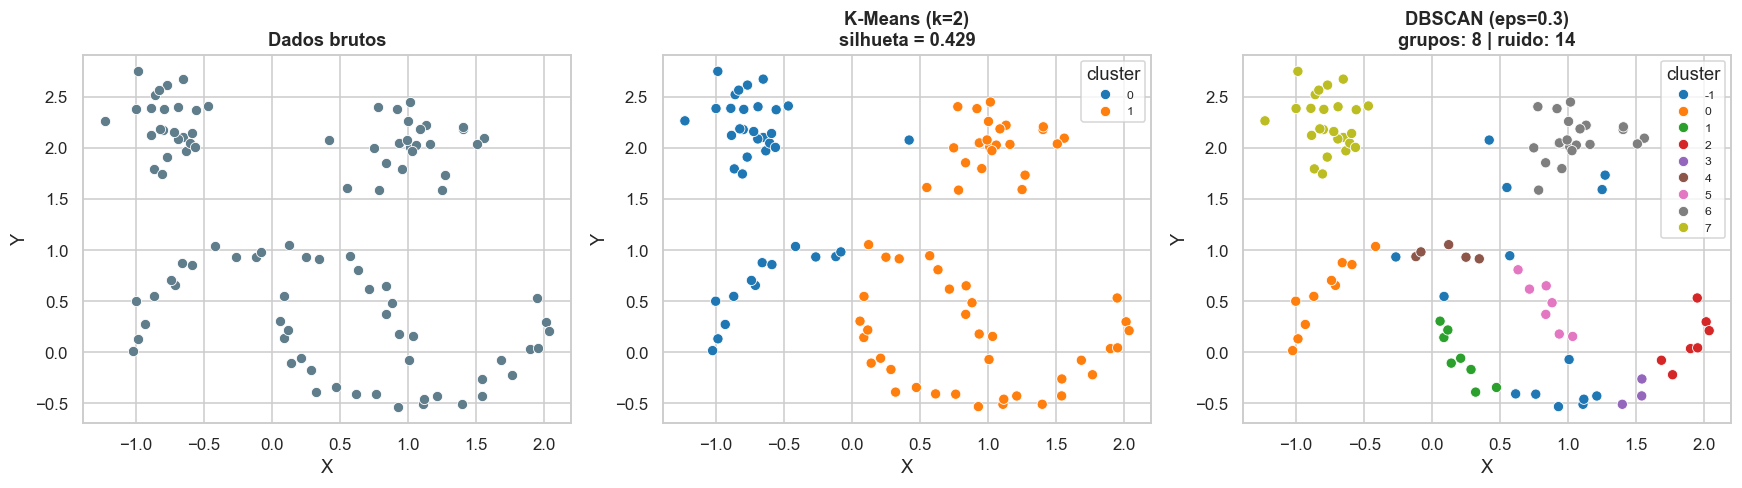

Licao: a silhueta do K-Means pode ate parecer razoavel, mas o agrupamento esta
geometricamente errado. Metrica boa nao substitui olhar para o resultado.


In [40]:
moons = pd.read_csv("data/moons.csv")
print(moons.shape)
X_moons = StandardScaler().fit_transform(moons[["X", "Y"]])

rot_km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_moons)
rot_db = DBSCAN(eps=0.3, min_samples=5).fit_predict(X_moons)

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.6))

sns.scatterplot(x=moons["X"], y=moons["Y"], ax=eixos[0], color="#607d8b", s=45)
eixos[0].set_title("Dados brutos")

sns.scatterplot(x=moons["X"], y=moons["Y"], hue=rot_km, palette="tab10", ax=eixos[1], s=45)
eixos[1].set_title(f"K-Means (k=2)\nsilhueta = {silhouette_score(X_moons, rot_km):.3f}")
eixos[1].legend(title="cluster", fontsize=8)

sns.scatterplot(x=moons["X"], y=moons["Y"], hue=rot_db, palette="tab10", ax=eixos[2], s=45)
n_ruido_m = int((rot_db == -1).sum())
eixos[2].set_title(f"DBSCAN (eps=0.3)\ngrupos: {len(set(rot_db) - {-1})} | ruido: {n_ruido_m}")
eixos[2].legend(title="cluster", fontsize=8)

plt.tight_layout(); plt.show()

print("Licao: a silhueta do K-Means pode ate parecer razoavel, mas o agrupamento esta")
print("geometricamente errado. Metrica boa nao substitui olhar para o resultado.")